Using device: cuda
patient_information.csv columns: ['LOG_ID', 'MRN', 'DISCH_DISP_C', 'DISCH_DISP', 'HOSP_ADMSN_TIME', 'HOSP_DISCH_TIME', 'LOS', 'ICU_ADMIN_FLAG', 'SURGERY_DATE', 'BIRTH_DATE', 'HEIGHT', 'WEIGHT', 'SEX', 'PRIMARY_ANES_TYPE_NM', 'ASA_RATING_C', 'ASA_RATING', 'PATIENT_CLASS_GROUP', 'PATIENT_CLASS_NM', 'PRIMARY_PROCEDURE_NM', 'IN_OR_DTTM', 'OUT_OR_DTTM', 'AN_START_DATETIME', 'AN_STOP_DATETIME']
(65728, 23)
Using OP_START_COL / OP_END_COL: IN_OR_DTTM OUT_OR_DTTM
Detected death-proxy column (DISCH_DISP-derived): DISCH_DISP
Detected ICU flag column: ICU_ADMIN_FLAG -- NOTE: no ICU timestamp exists, using any-ICU-this-stay instead.
Detected precomputed LOS column: LOS
Detected sex / antype / procedure columns: SEX PRIMARY_ANES_TYPE_NM PRIMARY_PROCEDURE_NM
EMOP proxy source column: PATIENT_CLASS_GROUP -- CAVEAT: Outpatient/Inpatient, NOT a true emergency-op flag.
BIRTH_DATE numeric-and-in-[0,110] fraction: 1.000
-> Treating BIRTH_DATE as AGE IN YEARS.
Parsed HEIGHT -> height (cm

[I 2026-09-12 17:55:09,241] A new study created in memory with name: no-name-21010c8f-3b36-4169-9081-e4fdafcf0822



=== Diversity-aware StackedEnsemble (NNLS_blend) ===
Test AUROC: 0.9025 +/- 0.0004
FeatureFusionNet trained on 25/60 selected features.
FeatureFusionNet branch sizes: {'vitals': 16, 'procedure': 3, 'static': 6}

--- Running Optuna Tuning for FeatureFusionNet ---


[I 2026-09-12 17:55:23,643] Trial 0 finished with value: 0.8858640211304597 and parameters: {'lr': 0.004625875049273797, 'dropout': 0.564170728932427, 'd_model': 64, 'use_attention_fusion': True, 'weight_decay': 0.0001357526938833545}. Best is trial 0 with value: 0.8858640211304597.
[I 2026-09-12 17:55:37,542] Trial 1 finished with value: 0.8883714646529135 and parameters: {'lr': 0.002701560119279151, 'dropout': 0.1714215667728695, 'd_model': 64, 'use_attention_fusion': True, 'weight_decay': 2.5143321536975745e-05}. Best is trial 1 with value: 0.8883714646529135.
[I 2026-09-12 17:55:47,261] Trial 2 finished with value: 0.88912632007023 and parameters: {'lr': 0.004725072483238972, 'dropout': 0.3339410559656234, 'd_model': 128, 'use_attention_fusion': False, 'weight_decay': 4.077445895841397e-06}. Best is trial 2 with value: 0.88912632007023.
[I 2026-09-12 17:56:01,357] Trial 3 finished with value: 0.8891879661383227 and parameters: {'lr': 0.0002597312388085527, 'dropout': 0.123494059636


Best Hyperparameters: {'lr': 0.0002597312388085527, 'dropout': 0.12349405963665619, 'd_model': 64, 'use_attention_fusion': True, 'weight_decay': 4.615452248352676e-05}
Best Validation AUROC (15-epoch proxy): 0.8892

--- Training final FeatureFusionNet with tuned hyperparameters ---

--- Training final FeatureFusionNet across 20 seeds (Revision 6: full 20-seed budget, was 5; tuned hyperparameters) ---
  [seed 0] FeatureFusionNet trained in 18.3s. val-AUROC=0.8891, test-AUROC=0.9025
  [seed 1] FeatureFusionNet trained in 18.6s. val-AUROC=0.8894, test-AUROC=0.9019
  [seed 2] FeatureFusionNet trained in 18.3s. val-AUROC=0.8899, test-AUROC=0.9016
  [seed 3] FeatureFusionNet trained in 18.6s. val-AUROC=0.8893, test-AUROC=0.9020
  [seed 4] FeatureFusionNet trained in 18.5s. val-AUROC=0.8899, test-AUROC=0.9015
  [seed 5] FeatureFusionNet trained in 18.3s. val-AUROC=0.8889, test-AUROC=0.9009
  [seed 6] FeatureFusionNet trained in 18.8s. val-AUROC=0.8886, test-AUROC=0.9014
  [seed 7] FeatureFus

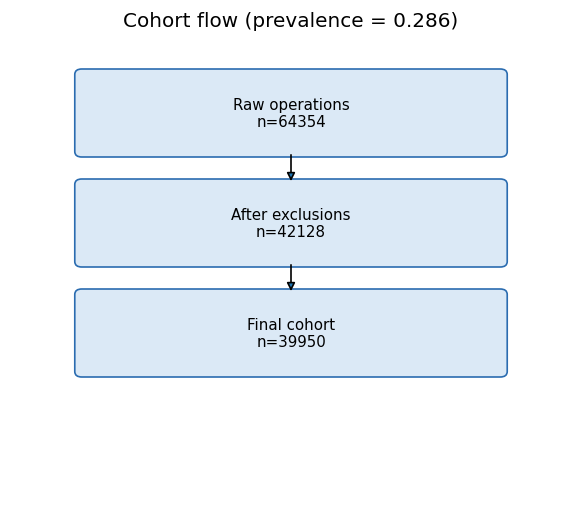

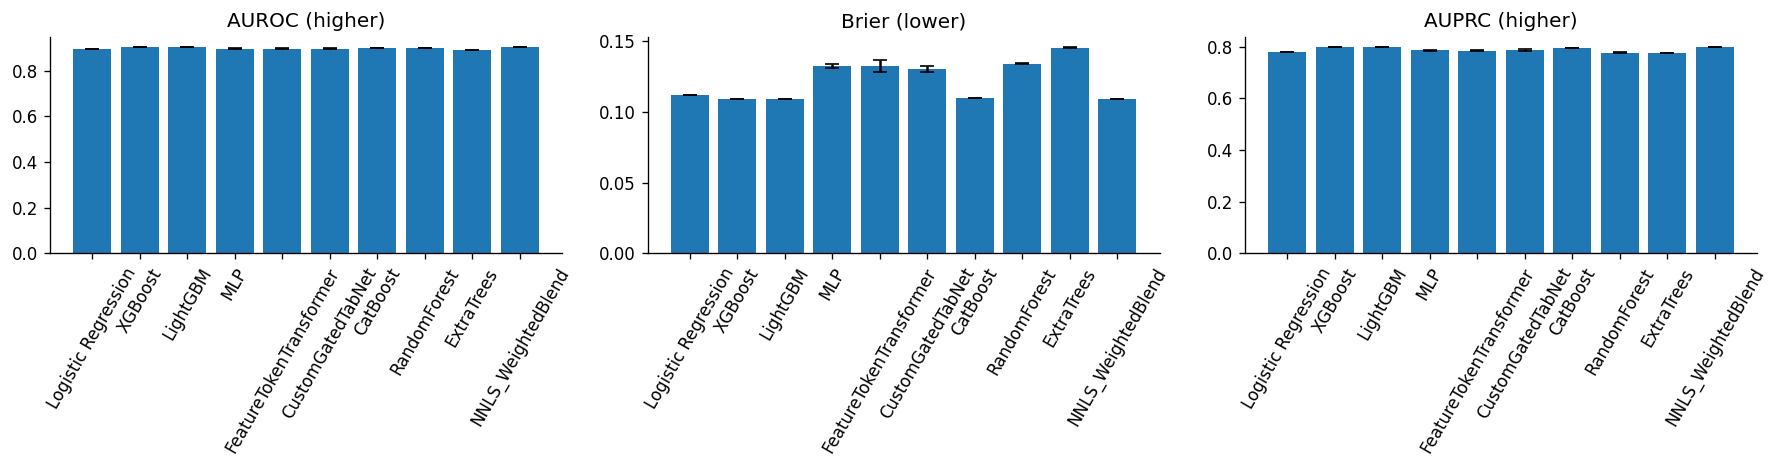

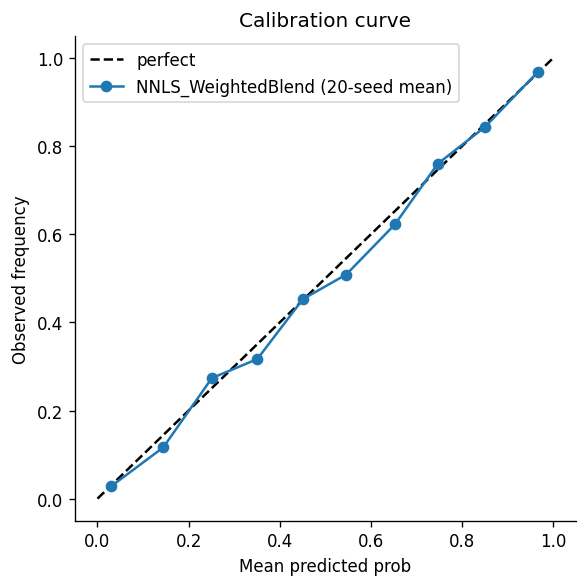

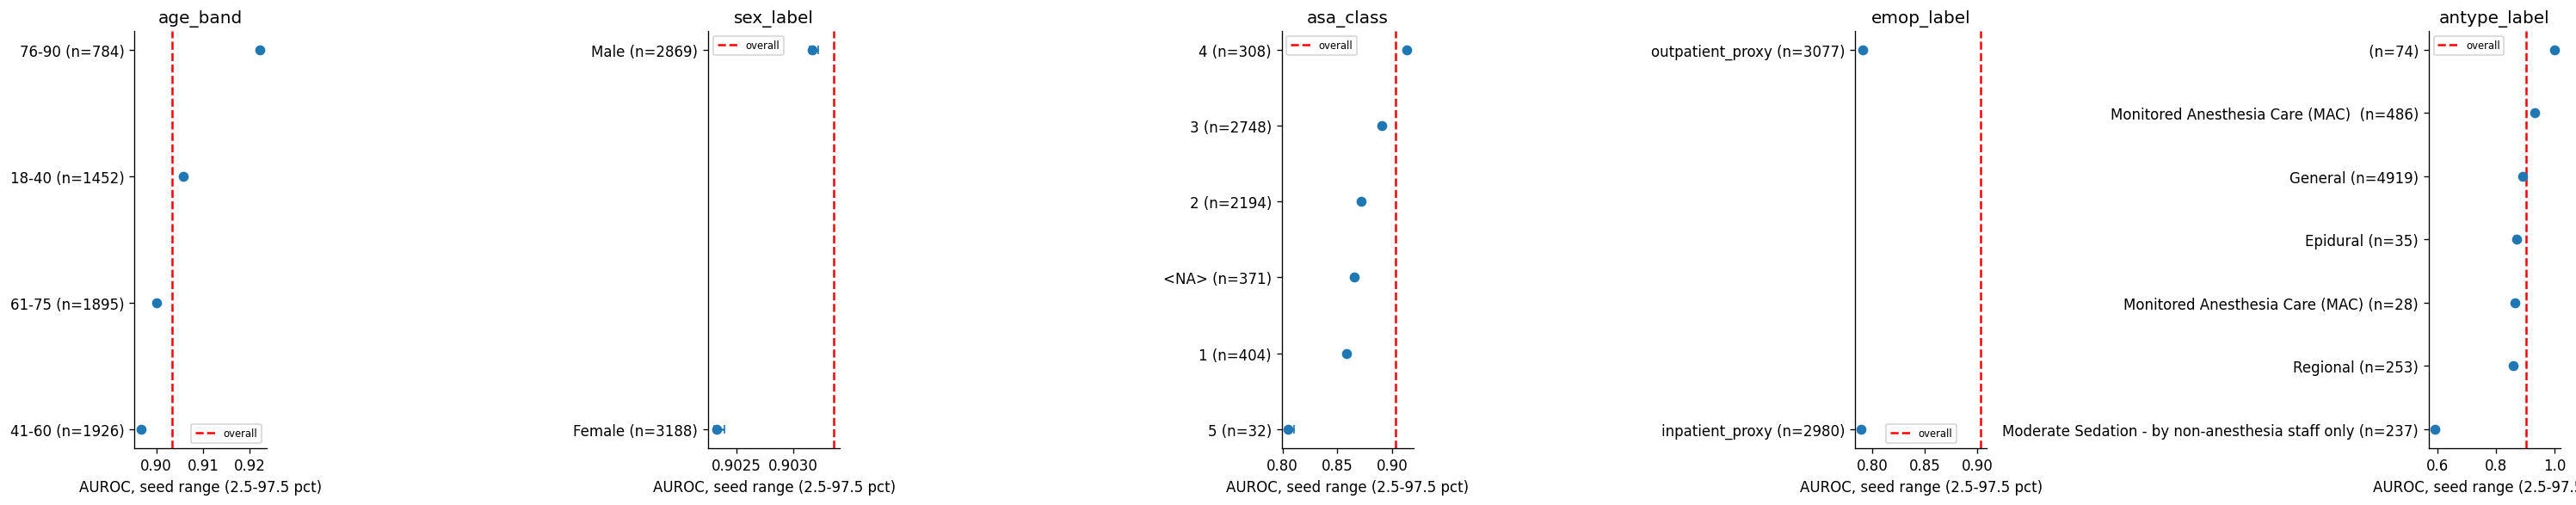

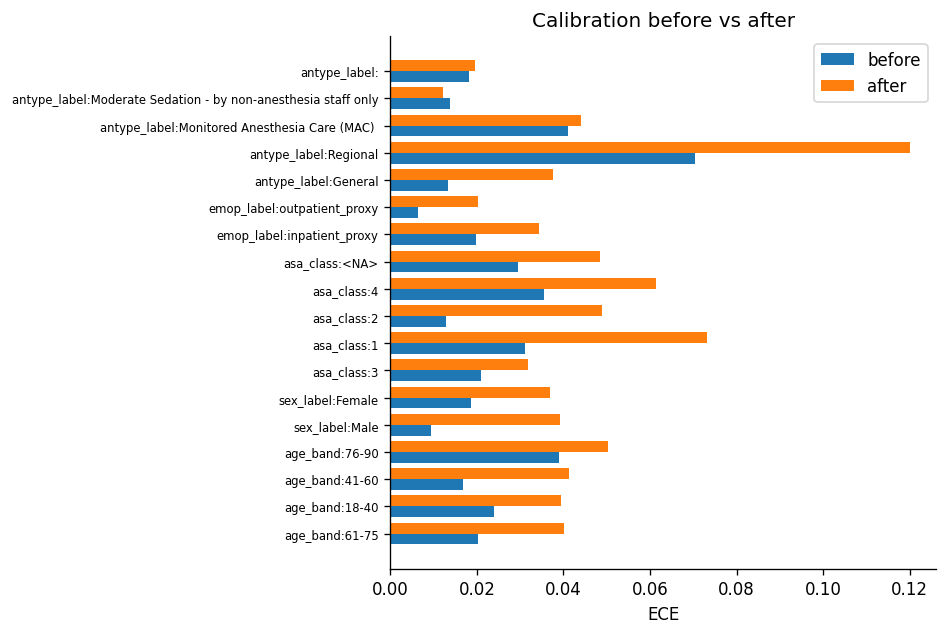

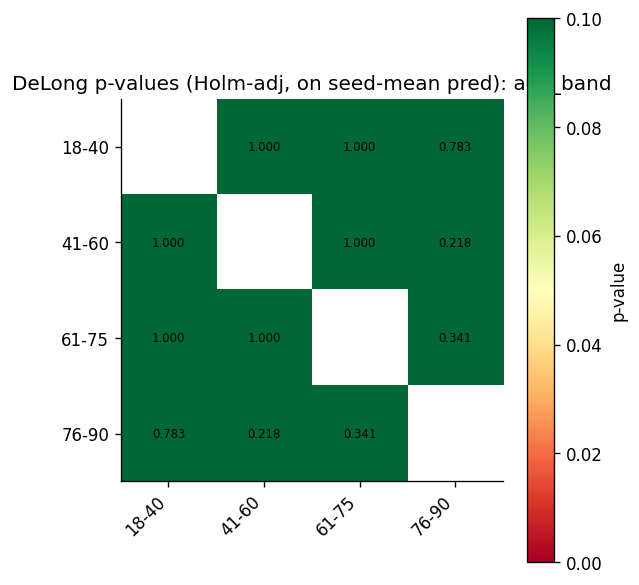

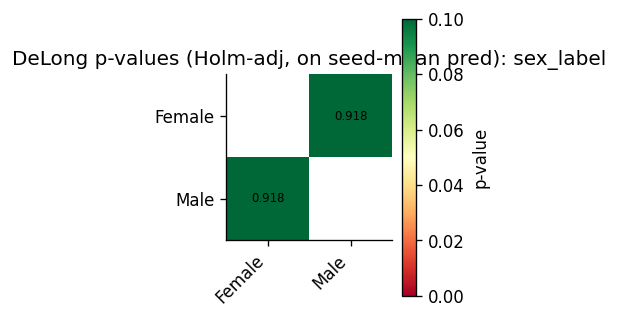

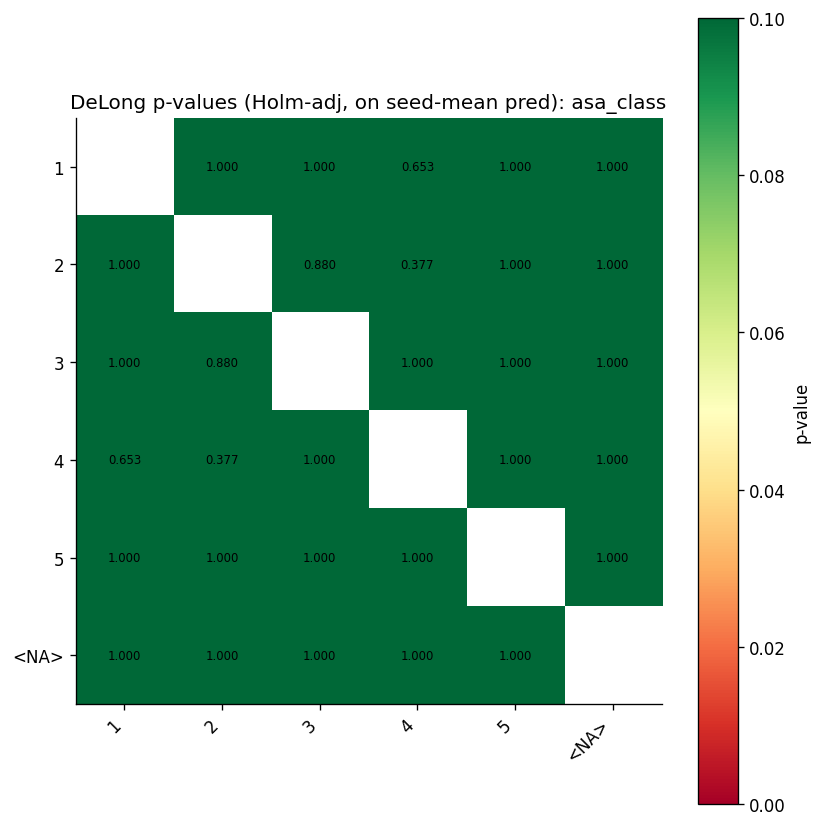

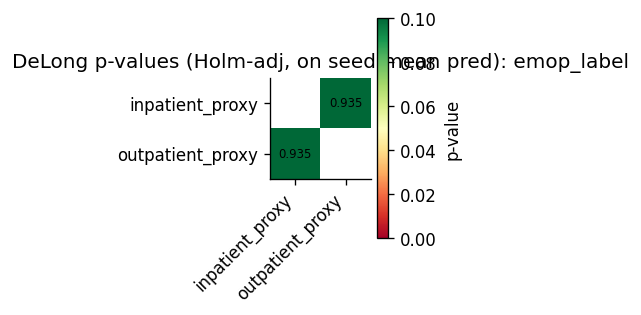

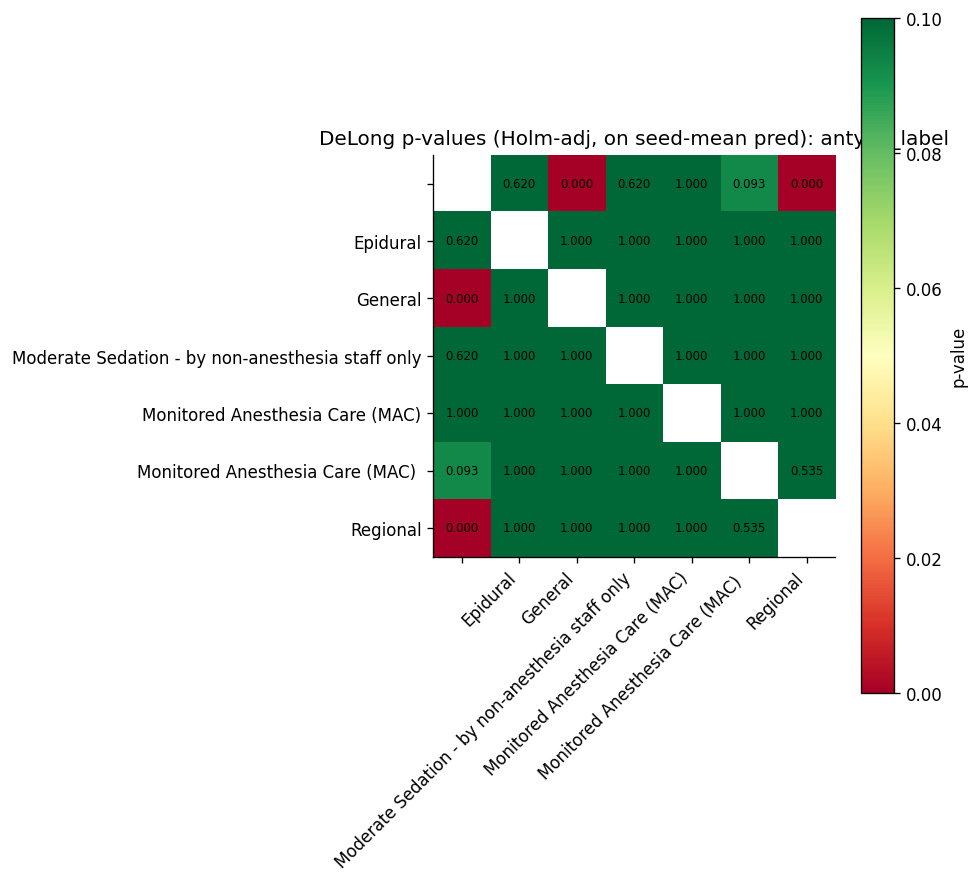

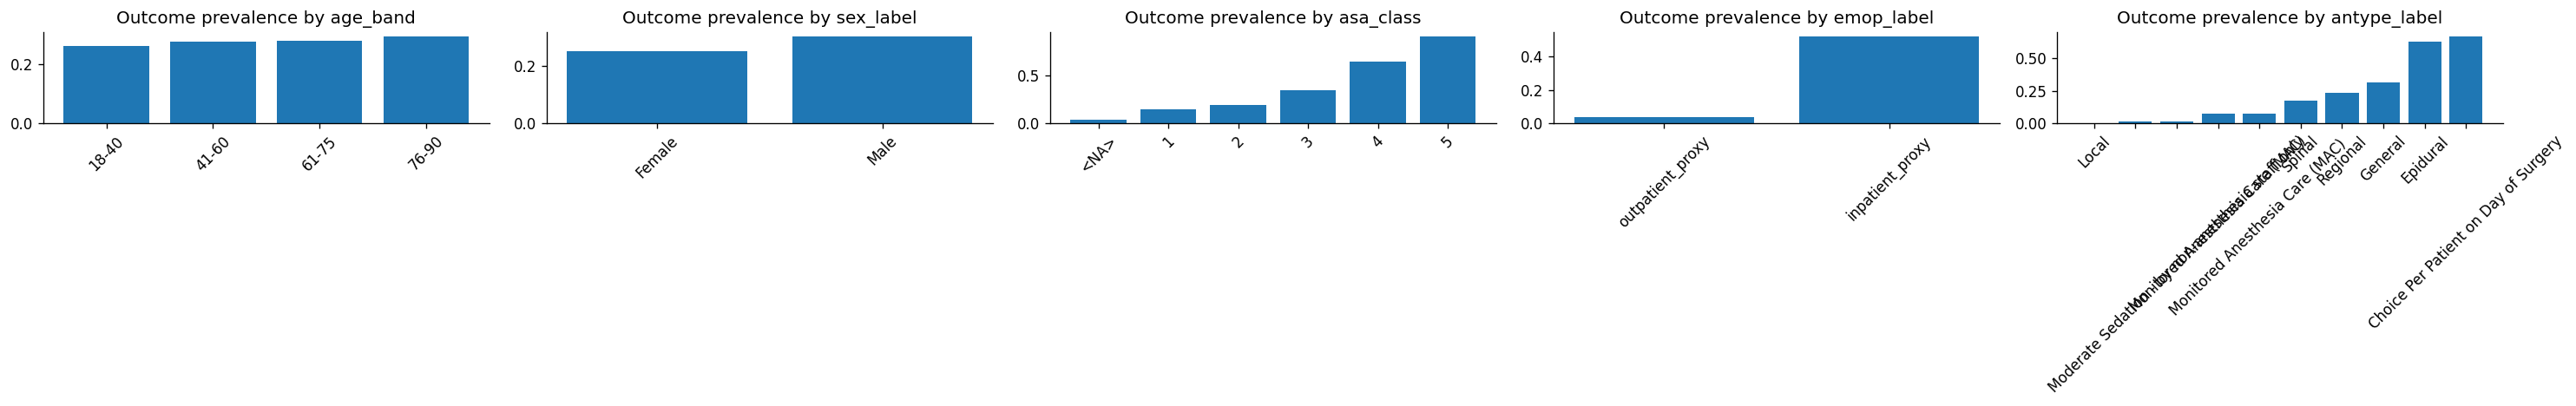

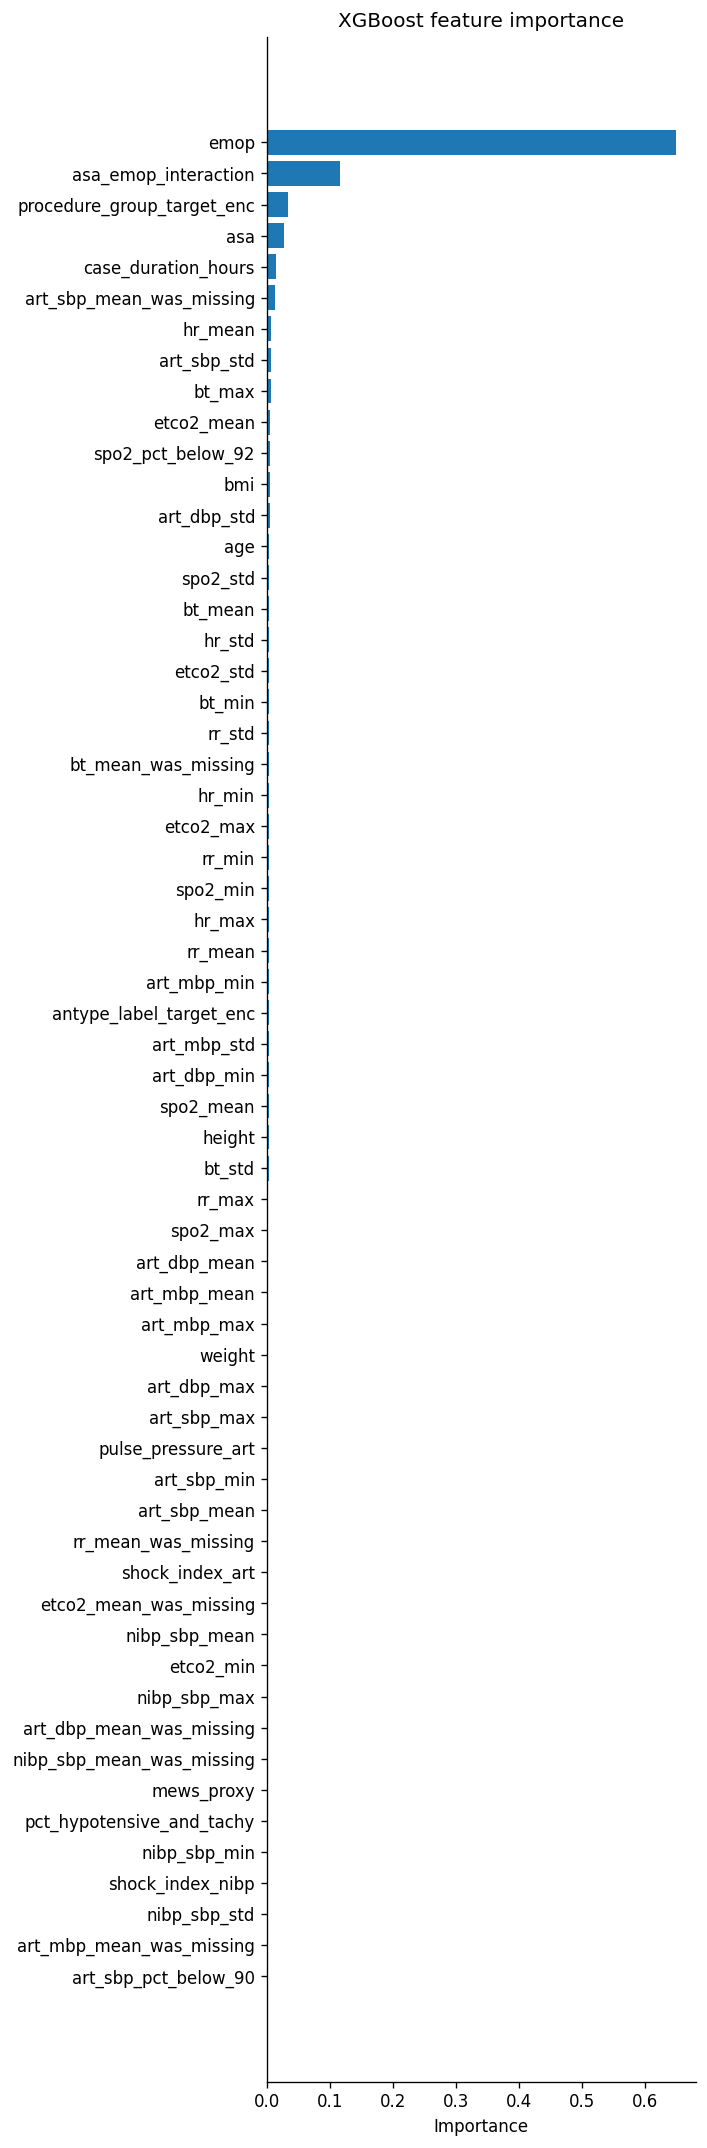


All figures saved under: /kaggle/working/figures
Retraining comparator model WITHOUT sensitive attributes across 20 seeds...
(BEST_MODEL='NNLS_WeightedBlend' is a blend/ensemble that cannot be directly retrained without sensitive attributes; using 'XGBoost' as the fixed with/without comparator.)
(with/without comparator: XGBoost, 20-seed mean AUROC per group)
                                           group    n  auroc_with  auroc_without      stratum
                                           41-60 1926    0.896064       0.896501     age_band
                                           61-75 1895    0.899726       0.899640     age_band
                                           18-40 1452    0.906350       0.902589     age_band
                                           76-90  784    0.921700       0.917784     age_band
                                          Female 3188    0.902132       0.901314    sex_label
                                            Male 2869    0.902944       0

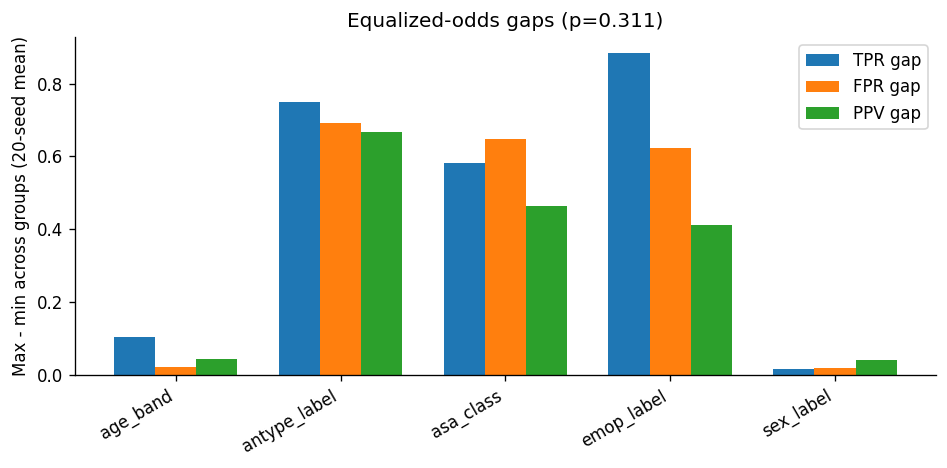

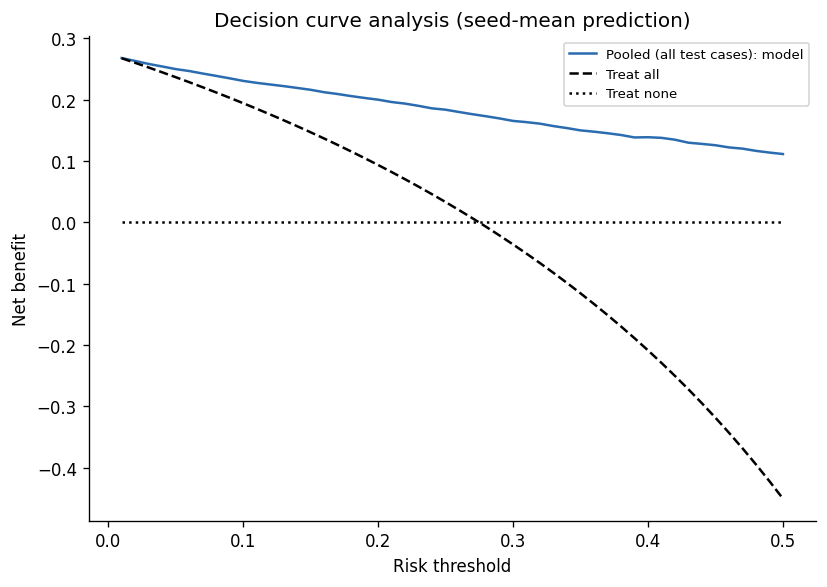

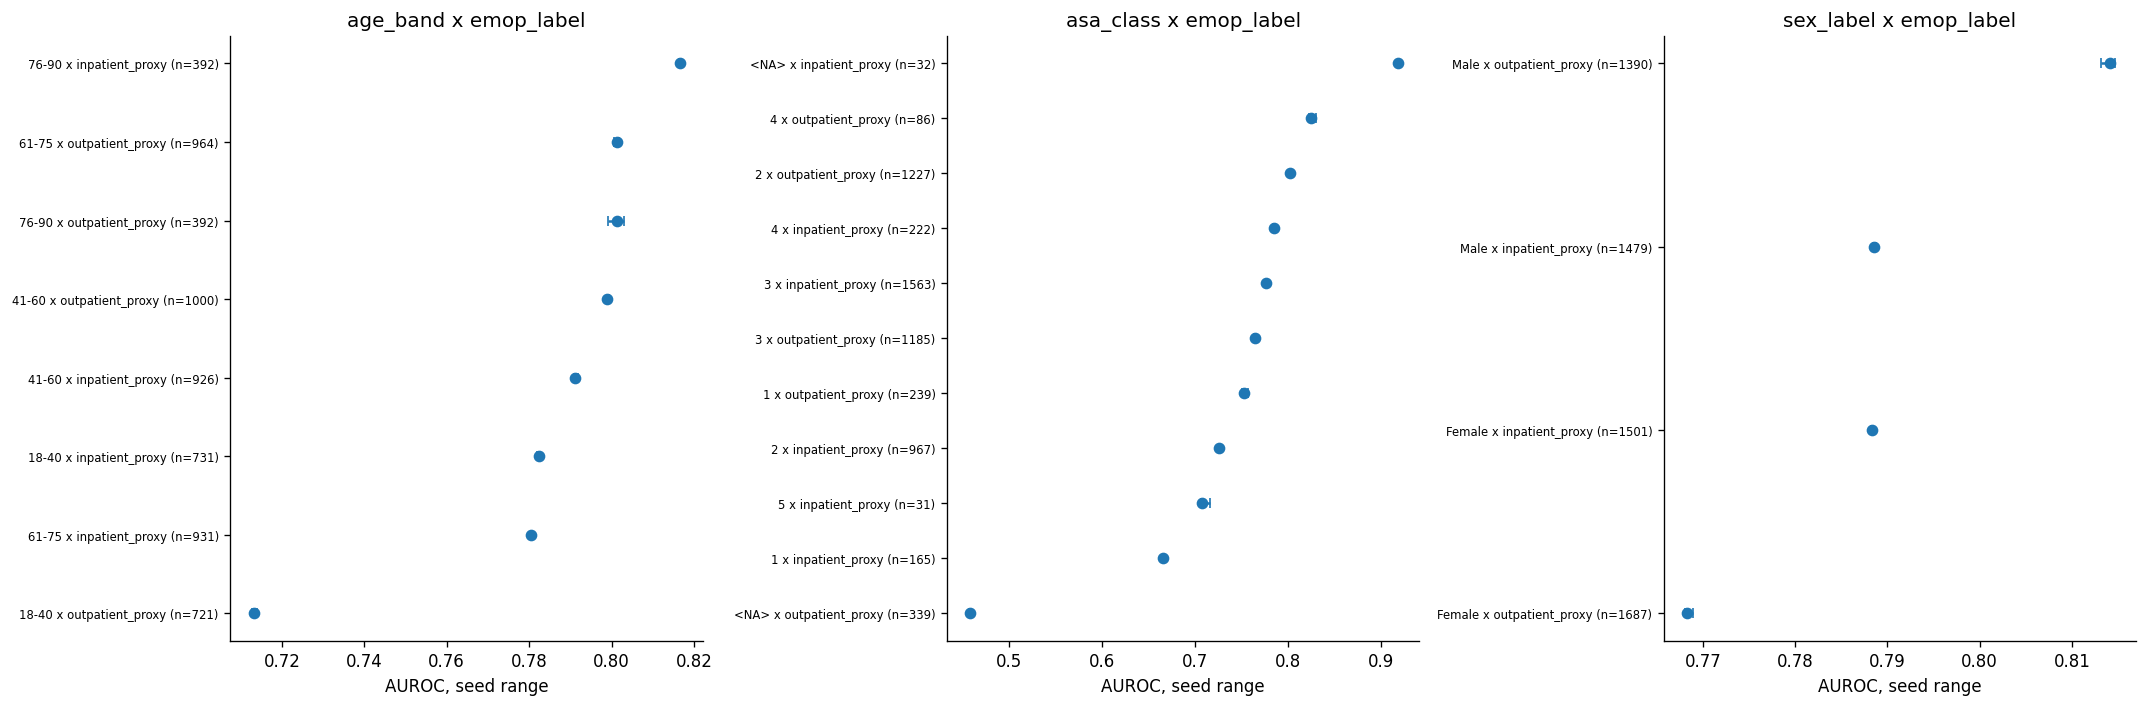


All outputs saved under /kaggle/working/
fairlearn not found -- installing (pip install fairlearn --quiet)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 2.6 MB/s eta 0:00:00

Training with EqualizedOdds constraint...
  Overall AUROC: 0.6859, gap: 0.0733

Training with DemographicParity constraint...
  Overall AUROC: 0.5831, gap: 0.0110

=== Mitigation comparison ===
                                          method  overall_auroc  emop_auroc_gap
                     In-training (EqualizedOdds)       0.685906        0.073323
                 In-training (DemographicParity)       0.583068        0.010950
Unconstrained (NNLS_WeightedBlend, 20-seed mean)       0.903358        0.001766

[LIMITATION] MOVER has no race/ethnicity column -- race fairness NOT COMPUTABLE.
[LIMITATION] MOVER has no department column -- dept analyses DISABLED.
[LIMITATION] emop_label is PATIENT_CLASS_GROUP proxy, NOT true emergency flag.
[LIMITATION] ICU component = 'any ICU during stay' (no timesta

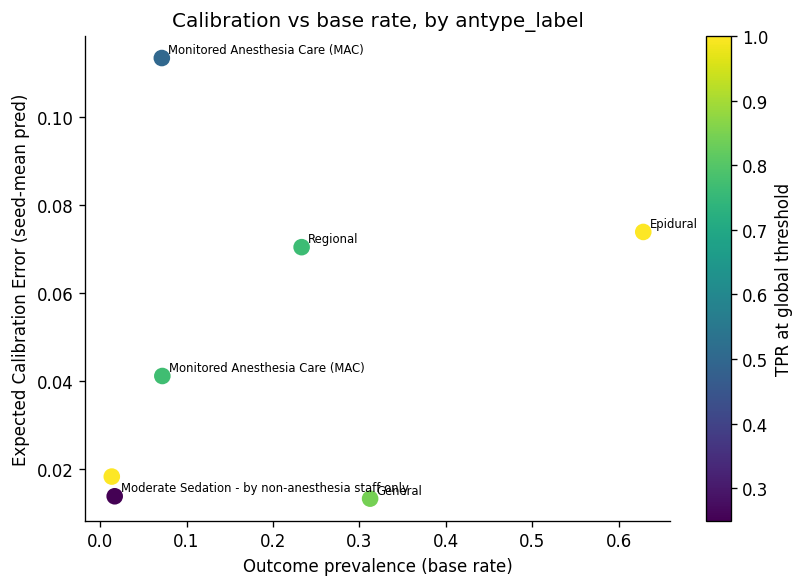


[REQUIRED] Calibration parity and equalized-odds parity are not 
simultaneously achievable. Report both as complementary views.
=== Absolute performance floor (AUROC >= 0.7, 20-seed mean AUROC per group) ===
     stratum                                            group    n    auroc  auroc_seed_std  below_minimum_floor
    age_band                                            41-60 1926 0.896727    8.590453e-05                False
    age_band                                            61-75 1895 0.900090    2.953678e-05                False
    age_band                                            18-40 1452 0.905774    4.875116e-05                False
    age_band                                            76-90  784 0.922225    3.583351e-05                False
   sex_label                                           Female 3188 0.902326    2.634531e-05                False
   sex_label                                             Male 2869 0.903162    2.150836e-05                False


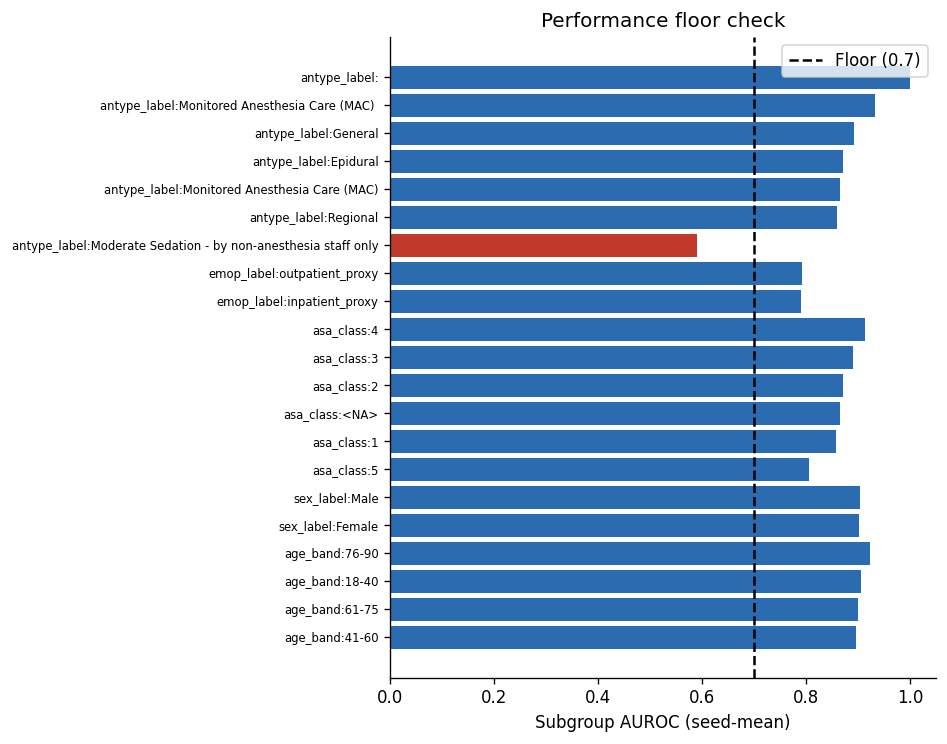


=== MOVER (Fairness-Audited, REVISION 6: DiversityStack / FeatureFusionNet / DGA-Net now on the full 20-seed budget, on top of the Revision 5 negative-xerr crash fix and the Revision 4 seed-expanded fairness audit) pipeline complete ===
Final selected model: NNLS_WeightedBlend
One-time pre-registered test AUROC: 0.9034 (95% bootstrap CI on the 20-seed mean: 0.8955-0.9114)
20-seed mean test AUROC (fairness-audit basis): 0.9034
See table7_full_model_comparison.csv for the full, honestly-seeded model comparison table (all candidates now n_seeds=20), case_duration_ablation.csv for the realized-duration robustness check, and subgroup_seed_stability.csv / fairness_<stratum>.csv for the Revision 4/6 seed-expanded fairness audit (now with Revision 5's clamped auroc_lo/auroc_hi bounds).


In [1]:
# ============================================================================
# FULL INTEGRATED NOTEBOOK
# Fairness-Aware Postoperative Outcome Prediction on MOVER
# (Version: OriginalStack_LGBMmeta REMOVED + UNIFIED STABLE SELECTOR
#           + REVISION 4: 20-seed fairness audit, mirrors the INSPIRE notebook
#           + REVISION 5: negative-xerr crash fix in the forest-plot figures
#           + REVISION 6: DiversityStack, FeatureFusionNet, and DGA-Net now
#             ALSO trained across the full 20-seed budget (was 5)
#
# *** REVISION 6 CHANGELOG (this revision) ***
#   Previously, three expensive candidates -- the diversity-aware stack
#   (DiversityStack_*), the Optuna-tuned FeatureFusionNet, and the
#   experimental DGA-Net -- were only trained across
#   CFG["expensive_model_n_seeds"] (5) seeds, while every classical/
#   boosting/MLP base model already had the full CFG["seeds"] (20) budget.
#   This meant that whenever the NNLS_WeightedBlend's small residual
#   weight landed on one of these three (e.g. FeatureFusionNet=0.05 in the
#   observed run), that slice of the blend contributed a CONSTANT
#   prediction at every one of the 20 fairness-audit seed indices, instead
#   of genuinely varying seed-to-seed.
#
#   This revision extends all three to the full CFG["seeds"] (20) budget:
#     (a) Cell 11f-run: DIVERSITY_STACK_SEEDS now = CFG["seeds"] (20),
#         was CFG["seeds"][:5]. The diversity-aware OOF stacking loop
#         (5-fold CV x 5 diverse base learners, refit from scratch every
#         seed) now runs 20 times instead of 5.
#     (b) Cell 11g-final: FUSION_EVAL_SEEDS now = CFG["seeds"] (20), was
#         CFG["seeds"][:CFG["expensive_model_n_seeds"]] (5). The
#         Optuna-tuned FeatureFusionNet is retrained from scratch with the
#         same tuned hyperparameters across all 20 seeds.
#     (c) Cell 11h-i: DGA_EVAL_SEEDS now = CFG["seeds"] (20), was
#         CFG["seeds"][:CFG["expensive_model_n_seeds"]] (5). DGA-Net is
#         retrained from scratch across all 20 seeds.
#   All three now report n_seeds=20 in TABLE 7, and any NNLS_WeightedBlend
#   weight mass that lands on them will genuinely vary across the full
#   fairness-audit seed range, not just the classical/boosting components.
#
#   COST NOTE: this roughly 4x's the wall-clock cost of Cells 11f-run,
#   11g-final, and 11h-i (5 -> 20 seeds each). No other cell's logic,
#   selection procedure, or downstream fairness-audit code changes -- Cell
#   11j / 12 onward already generically consume however many seeds
#   `all_test_preds[name]` holds for each candidate, so they automatically
#   benefit from the wider seed budget with no further edits required.
#
# *** REVISION 5 CHANGELOG (prior revision) ***
#   The Revision 4 notebook crashed at Cell 22 (fig11, the intersectional-
#   fairness forest plot) with:
#       ValueError: 'xerr' must not contain negative values
#   Root cause: subgroup_metrics_multiseed() computes "auroc" as the
#   across-seed MEAN (np.nanmean) and "auroc_lo"/"auroc_hi" as the
#   across-seed 2.5th/97.5th PERCENTILE (np.nanpercentile) of the SAME
#   underlying array, via two separate numpy routines. For groups where the
#   NNLS_WeightedBlend's seed-to-seed variance is at floating-point-epsilon
#   scale (e.g. auroc_seed_std ~1e-16 to ~1e-5, which happens whenever the
#   blend's dominant weight sits on a near-deterministic base learner like
#   XGBoost/LightGBM here), mean() and percentile() can disagree by a few
#   ULPs, occasionally putting auroc_lo fractionally ABOVE auroc_mean (or
#   auroc_hi fractionally BELOW it). matplotlib's errorbar() then receives a
#   technically-negative xerr (e.g. -1e-16) and raises ValueError.
#   This revision fixes it in two places (defense in depth):
#     (a) subgroup_metrics_multiseed() now clamps lo = min(lo, auroc_mean)
#         and hi = max(hi, auroc_mean) before returning, so auroc_lo <=
#         auroc <= auroc_hi is guaranteed by construction for every
#         downstream consumer of fairness_tables[...] / intersect_df
#         (Cell 12, 12c, 16, 19, 22, 28, 29, and the CSV outputs).
#     (b) Cell 15 (fig3) and Cell 22 (fig11), which build the errorbar plots
#         directly, ALSO clip the xerr arrays to be non-negative right
#         before calling ax.errorbar(), as a second, independent guard in
#         case any future edit reintroduces an unclamped table upstream.
#   No other cell's logic, seed budget, or reported numbers change in this
#   revision -- this is purely a plotting-robustness fix. All CSV outputs
#   are numerically identical except that auroc_lo/auroc_hi in
#   fairness_<stratum>.csv and intersectional_fairness.csv are now clamped
#   to bracket auroc_mean.
#
# *** REVISION 4 CHANGELOG (fairness audit seed expansion) ***
#   Prior versions ran the fairness audit (Cell 12 onward: subgroup AUROC/
#   Brier/AUPRC, DeLong tests, equalized-odds gaps, intersectional fairness,
#   calibration, decision-curve analysis, the impossibility disclosure, and
#   the performance-floor check) on a SINGLE seed's predictions
#   (best_preds_seed0), even though every one of the 9 classical/boosting/MLP
#   base models already had a full 20-seed budget (CFG["seeds"]) available.
#   This revision:
#     (a) Extends Cell 11j's NNLS_WeightedBlend evaluation from
#         CFG["expensive_model_n_seeds"] (5) seeds to the full CFG["seeds"]
#         (20) budget -- nnls_multiseed_test_preds now has 20 entries.
#     (b) Introduces subgroup_metrics_multiseed(), which runs
#         subgroup_metrics() independently per seed and reports the
#         across-seed MEAN AUROC/Brier/AUPRC per subgroup, with
#         "auroc_lo"/"auroc_hi" now the across-seed 2.5/97.5th percentile
#         (replacing the old within-seed bootstrap CI) and a new
#         "auroc_seed_std" column.
#     (c) Introduces best_preds_mean (mean prediction across all 20 seeds),
#         used wherever a downstream cell needs exactly ONE prediction
#         vector (calibration curve, DeLong test, decision-curve analysis,
#         the impossibility-disclosure tradeoff plot), replacing
#         best_preds_seed0 in those spots.
#     (d) Extends the sensitive-attribute-removal check (Cell 16), the
#         Youden-threshold equalized-odds check (Cell 17), and the
#         intersectional-fairness check (Cell 19) to the same 20-seed basis.
#
#   CAVEAT (Revision 6 removes most of this caveat -- see above): within
#   NNLS_WeightedBlend's 20-seed test predictions, the classical/boosting
#   base models (Logistic Regression, XGBoost, LightGBM, CatBoost,
#   RandomForest, ExtraTrees) genuinely retrain and vary across all 20
#   seeds (all already had a 20-seed budget from Cell 11/10c). As of
#   Revision 6, the neural single models (MLP, FeatureTokenTransformer,
#   CustomGatedTabNet) already varied across 20 seeds too, and the
#   ensemble candidates (FeatureFusionNet, DiversityStack, DGANet) NOW ALSO
#   genuinely retrain across the full 20-seed budget (previously only 5).
#
#   The single, one-time, pre-registered test-set evaluation of the selected
#   winner (winner_test_auroc / _brier / _auprc, fit on best_preds_seed0,
#   reported right after the selector in Cell 11h-i) is left UNCHANGED and
#   remains this study's headline, non-cherry-picked performance estimate --
#   the 20-seed fairness numbers are a separate, complementary robustness
#   analysis of subgroup-level gaps and training-stochasticity variance.
#
# *** BUGFIX APPLIED (carried over from the previous version) ***
#   Cell 11h-i and Cell 14 originally referenced an undefined variable
#   `candidates` when registering "LogisticBlend" and when looking up the
#   winning model's validation predictions. Every other place in the
#   selector correctly uses `stable_candidates`. Both occurrences of
#   `candidates` have been corrected to `stable_candidates` below.
#
# CHANGE LOG vs the previous full version (unrelated to the fairness-audit
# expansion, carried over unchanged):
#   - REMOVED the original same-feature 20-seed OOF stacking ensemble
#     ("OriginalStack_LGBMmeta" / old Cell 11b) and the model-ablation study
#     that existed only to analyze it.
#   - Diversity-aware stack, FeatureFusionNet, DGA-Net, blends, and the
#     automatic validation-based selector are UNCHANGED and still run.
#   - CELL 11h & 11i MERGED into a UNIFIED STABLE SELECTOR that prioritizes
#     NNLS_WeightedBlend if it is within 0.001 of the top validation AUROC.
#
# HOW TO USE: paste each "# %%" block into its own Kaggle cell, IN ORDER,
# top to bottom. Requires GPU (Settings -> Accelerator -> GPU T4/P100) and
# `pip install optuna fairlearn --quiet` if not already available.
#
# ============================================================================
# PARITY PATCHES APPLIED (see MOVER -> INSPIRE Parity Patches doc)
#   PATCH 1  - CFG: added min_subgroup_n, expensive_model_n_seeds
#   PATCH 2  - subgroup_metrics(): defensive np.clip on y_pred [CRASH FIX]
#   PATCH 3  - Cell 23: np.clip after mitigator._pmf_predict [CRASH FIX]
#              + fairlearn install-if-missing guard
#   PATCH 4  - Cell 17: Youden threshold fit on VALIDATION, not TEST
#              + CFG["min_subgroup_n"] used consistently in 12b/12c/17/19/27/28/29
#   PATCH 5  - FeatureFusionNet trained across expensive_model_n_seeds seeds
#              [REVISION 6: now trained across the FULL 20-seed budget]
#   PATCH 6  - DGA-Net trained across expensive_model_n_seeds seeds
#              [REVISION 6: now trained across the FULL 20-seed budget]
#   PATCH 7  - Added Cell 11l (case-duration ablation) + Cell 12b-dur
#              (per-subgroup case-duration ablation)
#   PATCH 8  - Added Cell 11m (pooled AUROC bootstrap CI)
#   PATCH 9  - Added Cell 11j (NNLS_WeightedBlend multi-seed) + Cell 11k
#              (TABLE 7 full model comparison)
#   PATCH 10 - Cell 29 closing summary updated to report bootstrap CI and
#              point to table7_full_model_comparison.csv /
#              case_duration_ablation.csv
#   PATCH 11 (Revision 4) - Fairness audit (Cell 12 onward) now runs on the
#              full 20-seed NNLS_WeightedBlend prediction set instead of a
#              single seed. See the Revision 4 changelog above.
#   PATCH 12 (Revision 5) - subgroup_metrics_multiseed() clamps auroc_lo/
#              auroc_hi to bracket auroc_mean; Cell 15 (fig3) and Cell 22
#              (fig11) additionally clip xerr to be non-negative before
#              plotting. Fixes "ValueError: 'xerr' must not contain
#              negative values" at Cell 22. See Revision 5 changelog above.
#   PATCH 13 (Revision 6) - DiversityStack (Cell 11f-run), FeatureFusionNet
#              (Cell 11g-final), and DGA-Net (Cell 11h-i) now trained
#              across the FULL CFG["seeds"] (20) budget instead of just
#              CFG["expensive_model_n_seeds"] (5). See Revision 6 changelog
#              above.
# ============================================================================

# %% [Cell 1] Imports & config -----------------------------------------------
import os, random, math, json, time, warnings, re, gc
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

MOVER_BASE = "/kaggle/input/datasets/pritom96/mover1"
FLOWSHEET_DIR = f"{MOVER_BASE}/Epic_flowsheets_cleaned/flowsheets_cleaned"
PATIENT_INFO_PATH = f"{MOVER_BASE}/patient_information.csv"

FIG_DIR = "/kaggle/working/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(fig, name, dpi=300):
    fig.savefig(f"{FIG_DIR}/{name}.png", dpi=dpi, bbox_inches="tight")
    fig.savefig(f"{FIG_DIR}/{name}.pdf", bbox_inches="tight")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if DEVICE.type == "cpu":
    print("WARNING: no GPU detected. Enable Settings -> Accelerator -> GPU T4/P100.")

CFG = dict(
    icu_window_hours   = 24,
    los_prolonged_days  = 14,
    batch_size          = 256,
    lr                  = 1e-3,
    epochs               = 20,
    d_model              = 64,
    nhead                = 4,
    enc_layers           = 2,
    dropout              = 0.2,
    seeds                = list(range(20)),
    n_bootstrap          = 1000,
    fairness_auroc_gap_threshold = 0.05,
    min_subgroup_n       = 20,
    expensive_model_n_seeds = 5,   # [REVISION 6] no longer used to cap
                                    # DiversityStack / FeatureFusionNet /
                                    # DGA-Net -- kept only for backward
                                    # compatibility / reference. All three
                                    # now use the full CFG["seeds"] budget.
    flowsheet_chunksize  = 2_000_000,
    top_k_procedures     = 200,
)
NEURAL_SEEDS = CFG["seeds"]

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(0)


# %% [Cell 2] Load patient_information.csv ------------------------------------
operations = pd.read_csv(PATIENT_INFO_PATH)
print("patient_information.csv columns:", list(operations.columns))
print(operations.shape)

OP_ID_COL = "LOG_ID"
SUBJ_COL  = "MRN"
HADM_COL  = "LOG_ID"
ADM_START_COL = "HOSP_ADMSN_TIME"
ADM_END_COL   = "HOSP_DISCH_TIME"
OP_START_COL = "IN_OR_DTTM"
OP_END_COL   = "OUT_OR_DTTM"
print("Using OP_START_COL / OP_END_COL:", OP_START_COL, OP_END_COL)

# --- Death column: search DISCH_DISP for "expired"-type category ---
DEATH_COL = None
if "DISCH_DISP" in operations.columns:
    disch_vals = operations["DISCH_DISP"].astype(str).str.lower()
    if disch_vals.str.contains("expired|deceased|death", regex=True, na=False).any():
        DEATH_COL = "DISCH_DISP"
print("Detected death-proxy column (DISCH_DISP-derived):", DEATH_COL)

# ICU: only a Yes/No flag, no timestamp
ICU_FLAG_COL = "ICU_ADMIN_FLAG" if "ICU_ADMIN_FLAG" in operations.columns else None
print("Detected ICU flag column:", ICU_FLAG_COL,
      "-- NOTE: no ICU timestamp exists, using any-ICU-this-stay instead.")

LOS_PRECOMPUTED_COL = "LOS" if "LOS" in operations.columns else None
print("Detected precomputed LOS column:", LOS_PRECOMPUTED_COL)

SEX_COL = "SEX" if "SEX" in operations.columns else None
DEPT_COL = None   # genuinely absent in MOVER
RACE_COL = None   # genuinely absent in MOVER
ANTYPE_COL = "PRIMARY_ANES_TYPE_NM" if "PRIMARY_ANES_TYPE_NM" in operations.columns else None
PROC_COL = "PRIMARY_PROCEDURE_NM" if "PRIMARY_PROCEDURE_NM" in operations.columns else None
print("Detected sex / antype / procedure columns:", SEX_COL, ANTYPE_COL, PROC_COL)

# --- EMOP: no clean binary flag, use PATIENT_CLASS_GROUP as proxy ---
EMOP_SOURCE_COL = None
if "PATIENT_CLASS_GROUP" in operations.columns:
    EMOP_SOURCE_COL = "PATIENT_CLASS_GROUP"
print("EMOP proxy source column:", EMOP_SOURCE_COL,
      "-- CAVEAT: Outpatient/Inpatient, NOT a true emergency-op flag.")

# --- Age: BIRTH_DATE is actually AGE in years ---
if "BIRTH_DATE" in operations.columns:
    bd_numeric = pd.to_numeric(operations["BIRTH_DATE"], errors="coerce")
    plausible_age_fraction = bd_numeric.between(0, 110).mean()
    print(f"BIRTH_DATE numeric-and-in-[0,110] fraction: {plausible_age_fraction:.3f}")
    if plausible_age_fraction > 0.95:
        operations["age"] = bd_numeric
        print("-> Treating BIRTH_DATE as AGE IN YEARS.")
    else:
        raise ValueError("BIRTH_DATE does not look like a plausible age column.")
else:
    raise ValueError("No BIRTH_DATE/age-equivalent column found.")

# --- Height: text like "5' 6" -> parse to cm ---
def parse_height_to_cm(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    m = re.match(r"^(\d+)\D+(\d+)?", s)
    if not m:
        return np.nan
    feet = int(m.group(1))
    inches = int(m.group(2)) if m.group(2) else 0
    return round((feet * 12 + inches) * 2.54, 1)

if "HEIGHT" in operations.columns:
    operations["height"] = operations["HEIGHT"].apply(parse_height_to_cm)
    print(f"Parsed HEIGHT -> height (cm). Median: {operations['height'].median():.1f} cm")
else:
    operations["height"] = np.nan

# --- Weight: raw values, flag implausible units ---
if "WEIGHT" in operations.columns:
    w = pd.to_numeric(operations["WEIGHT"], errors="coerce")
    print(f"Raw WEIGHT stats -- median: {w.median():.2f}, 5th: {w.quantile(.05):.2f}, 95th: {w.quantile(.95):.2f}")
    if w.median() > 400:
        print("WARNING: median WEIGHT looks implausible for kg. Proceeding with raw values.")
    operations["weight"] = w
else:
    operations["weight"] = np.nan

STATIC_COLS = ["age", "weight", "height", "asa"]
operations["asa"] = pd.to_numeric(operations.get("ASA_RATING_C"), errors="coerce")

for col in (ADM_START_COL, ADM_END_COL, OP_START_COL, OP_END_COL):
    if col not in operations.columns:
        raise ValueError(f"Missing '{col}'. Check the MOVER schema.")

# --- Parse timestamps ---
for col in (ADM_START_COL, ADM_END_COL, OP_START_COL, OP_END_COL,
            "AN_START_DATETIME", "AN_STOP_DATETIME", "SURGERY_DATE"):
    if col in operations.columns:
        operations[col] = pd.to_datetime(operations[col], errors="coerce")


# %% [Cell 2c] Diagnose + fix duplicate LOG_ID in operations -----------------
dup_mask = operations[OP_ID_COL].duplicated(keep=False)
n_dup_logid = operations[OP_ID_COL].duplicated().sum()
print(f"Duplicate {OP_ID_COL} rows in `operations`: {n_dup_logid}")

if n_dup_logid > 0:
    dup_rows = operations[dup_mask].sort_values(OP_ID_COL)
    n_ids_affected = dup_rows[OP_ID_COL].nunique()
    print(f"{n_ids_affected} distinct {OP_ID_COL} values have duplicates.")

    sample_id = dup_rows[OP_ID_COL].iloc[0]
    sample = operations[operations[OP_ID_COL] == sample_id]
    varying_cols = [c for c in sample.columns if sample[c].nunique(dropna=False) > 1]
    print(f"\nSample duplicated {OP_ID_COL} = {sample_id!r}, {len(sample)} rows.")

    def _cols_that_vary_within_group(g):
        return [c for c in g.columns if g[c].nunique(dropna=False) > 1]

    all_varying = set()
    for _, g in dup_rows.groupby(OP_ID_COL):
        all_varying.update(_cols_that_vary_within_group(g))
    all_varying.discard(OP_ID_COL)
    print(f"\nUnion of columns that vary within ANY duplicated group: {sorted(all_varying)}")

    if len(all_varying) == 0:
        n_before = len(operations)
        operations = operations.drop_duplicates(subset=OP_ID_COL, keep="first").copy()
        print(f"Dropped {n_before - len(operations)} exact-duplicate rows.")
    else:
        print(f"\n-> Duplicate rows differ in: {sorted(all_varying)}. Collapsing via aggregation.")
        id_level_cols = [c for c in operations.columns if c not in all_varying and c != OP_ID_COL]
        agg_spec = {}
        for c in id_level_cols:
            agg_spec[c] = "first"
        for c in all_varying:
            if operations[c].dtype == object or str(operations[c].dtype).startswith("category"):
                agg_spec[c] = lambda s: " | ".join(sorted(set(s.dropna().astype(str))))
            else:
                agg_spec[c] = "max"
                print(f"  NOTE: numeric column '{c}' varies -- using max() as default.")
        n_before = len(operations)
        operations = operations.groupby(OP_ID_COL, as_index=False).agg(agg_spec)
        print(f"Collapsed {n_before} rows -> {len(operations)} rows.")

    remaining_dups = operations[OP_ID_COL].duplicated().sum()
    print(f"\n{OP_ID_COL} duplicates remaining: {remaining_dups}")
else:
    print(f"No duplicate {OP_ID_COL} values found.")

assert operations[OP_ID_COL].is_unique, f"{OP_ID_COL} is still not unique."
print(f"\nConfirmed: {OP_ID_COL} is unique ({len(operations)} rows).")


# %% [Cell 2b] Cohort exclusions ----------------------------------------------
n_ops_start = len(operations)

adm_windows = operations.drop_duplicates(HADM_COL)[[SUBJ_COL, HADM_COL, ADM_START_COL, ADM_END_COL]]
multi_subj = adm_windows.groupby(SUBJ_COL).filter(lambda g: len(g) > 1)

def _find_overlap(g):
    g = g.sort_values(ADM_START_COL)
    prev_end = None
    for _, row in g.iterrows():
        if prev_end is not None and pd.notna(row[ADM_START_COL]) and pd.notna(prev_end) \
                and row[ADM_START_COL] < prev_end:
            return True
        prev_end = row[ADM_END_COL]
    return False

overlapping_subjects = {s for s, g in multi_subj.groupby(SUBJ_COL) if _find_overlap(g)}
n_before = len(operations)
operations = operations[~operations[SUBJ_COL].isin(overlapping_subjects)].copy()
print(f"Dropped {n_before - len(operations)} ops (overlapping admission windows).")

bad_opend_mask = (
    operations[OP_END_COL].notna() & operations[ADM_START_COL].notna() & operations[ADM_END_COL].notna() &
    ((operations[OP_END_COL] < operations[ADM_START_COL]) |
     (operations[OP_END_COL] > operations[ADM_END_COL]))
)
n_before = len(operations)
operations = operations[~bad_opend_mask].copy()
print(f"Dropped {n_before - len(operations)} ops (OR-out time outside admission window).")

before = len(operations)
operations = operations.dropna(subset=[ADM_START_COL, ADM_END_COL]).copy()
print(f"Dropped {before - len(operations)} ops (missing core timestamps).")

before = len(operations)
operations = operations[(operations["age"] >= 18) & (operations["age"] <= 90)].copy()
print(f"Dropped {before - len(operations)} ops (age outside 18-90).")

n_ops_total = len(operations)
print(f"\nTotal operations after exclusions: {n_ops_total} / {n_ops_start} ({100*n_ops_total/max(n_ops_start,1):.2f}%)")


# %% [Cell 3] Timestamp handling + composite outcome label -------------------
operations["los_days"] = (operations[ADM_END_COL] - operations[ADM_START_COL]).dt.total_seconds() / 86400.0

if LOS_PRECOMPUTED_COL is not None:
    los_diff = (operations["los_days"] - operations[LOS_PRECOMPUTED_COL]).abs()
    print(f"QA: computed los_days vs precomputed LOS -- median diff: {los_diff.median():.3f} days")

if DEATH_COL is not None:
    death_inhosp = operations["DISCH_DISP"].astype(str).str.lower().str.contains(
        "expired|deceased|death", regex=True, na=False)
    print(f"Death-proxy prevalence: {death_inhosp.mean():.4f} ({death_inhosp.sum()})")
else:
    death_inhosp = pd.Series(False, index=operations.index)
    print("WARNING: no death-proxy signal found.")

if ICU_FLAG_COL is not None:
    icu_early = operations[ICU_FLAG_COL].astype(str).str.strip().str.lower().eq("yes")
    print(f"ICU-admission-this-stay prevalence: {icu_early.mean():.4f} ({icu_early.sum()})")
else:
    icu_early = pd.Series(False, index=operations.index)
    print("WARNING: no ICU_ADMIN_FLAG column found.")

los_prolonged = operations["los_days"] > CFG["los_prolonged_days"]

operations["outcome"] = (death_inhosp | icu_early | los_prolonged).astype(int)

print(f"\nComposite outcome prevalence: {operations['outcome'].mean():.4f}")
print(f"  death component: {death_inhosp.mean():.4f}")
print(f"  ICU component: {icu_early.mean():.4f}")
print(f"  prolonged-LOS: {los_prolonged.mean():.4f}")


# %% [Cell 3-alt] LABEL-CEILING DIAGNOSTIC + optional label switch -----------
print("=== Composite-label ceiling diagnostic ===")
print(f"death component prevalence: {death_inhosp.mean():.4f} (n={death_inhosp.sum()})")
print(f"icu component prevalence: {icu_early.mean():.4f} (n={icu_early.sum()})")
print(f"los component prevalence: {los_prolonged.mean():.4f} (n={los_prolonged.sum()})")
print(f"overlap death&icu: {(death_inhosp & icu_early).sum()}")
print(f"overlap death&los: {(death_inhosp & los_prolonged).sum()}")
print(f"overlap icu&los: {(icu_early & los_prolonged).sum()}")

USE_LABEL_VARIANT = "no_death"

if USE_LABEL_VARIANT == "no_death":
    operations["outcome"] = (icu_early | los_prolonged).astype(int)
    print("\n[LABEL SWITCH] outcome redefined as (icu_this_stay OR los_prolonged)")
elif USE_LABEL_VARIANT == "icu_only":
    operations["outcome"] = icu_early.astype(int)
elif USE_LABEL_VARIANT == "los_only":
    operations["outcome"] = los_prolonged.astype(int)

print(f"\nFinal outcome prevalence: {operations['outcome'].mean():.4f}")


# %% [Cell 4] Streamed intraoperative vitals aggregation ---------------------
ITEM_NAME_MAP = {
    "art_sbp":  ["Arterial Line BP (ART)", "Max Systolic", "Min Systolic"],
    "art_dbp":  ["Arterial Line BP (ART)", "Max Diastolic", "Min Diastolic"],
    "art_mbp":  ["Arterial Line MAP (ART)", "MAP (mmHg)"],
    "hr":       ["Pulse", "Heart Rate"],
    "spo2":     ["SpO2"],
    "rr":       ["Resp"],
    "bt":       ["Temp"],  # FIX: was "Temp source" (categorical), now "Temp" (numeric)
    "etco2":    ["ETCO2", "ETN2O"],
    "nibp_sbp": ["Max Systolic", "Min Systolic"],
}
PCT_THRESHOLDS = {"art_sbp": 90, "spo2": 92}

flowsheet_files = sorted(f for f in os.listdir(FLOWSHEET_DIR) if f.endswith(".csv"))
print(f"Found {len(flowsheet_files)} flowsheet part files to stream.")

VALID_OP_IDS = set(operations[OP_ID_COL].unique())

from collections import defaultdict
acc = defaultdict(lambda: [0, 0.0, 0.0, np.inf, -np.inf, 0])

flo_to_canonical = defaultdict(list)
for canon, flo_names in ITEM_NAME_MAP.items():
    for flo in flo_names:
        flo_to_canonical[flo].append(canon)

USE_COLS = ["LOG_ID", "FLO_DISPLAY_NAME", "RECORD_TYPE", "RECORDED_TIME", "MEAS_VALUE"]

t0 = time.time()
n_rows_seen, n_rows_used = 0, 0
for fname in flowsheet_files:
    fpath = os.path.join(FLOWSHEET_DIR, fname)
    print(f"  streaming {fname} ...")
    try:
        reader = pd.read_csv(fpath, usecols=lambda c: c.strip() in USE_COLS or c in USE_COLS,
                             chunksize=CFG["flowsheet_chunksize"], low_memory=False)
    except ValueError:
        reader = pd.read_csv(fpath, chunksize=CFG["flowsheet_chunksize"], low_memory=False)

    for chunk in reader:
        chunk.columns = [c.strip() for c in chunk.columns]
        n_rows_seen += len(chunk)
        chunk = chunk[chunk["FLO_DISPLAY_NAME"].isin(flo_to_canonical.keys())]
        if "LOG_ID" not in chunk.columns:
            continue
        chunk = chunk[chunk["LOG_ID"].isin(VALID_OP_IDS)]
        if "RECORD_TYPE" in chunk.columns:
            chunk = chunk[chunk["RECORD_TYPE"].isna() | (chunk["RECORD_TYPE"] == "INTRA-OP")]
        if len(chunk) == 0:
            continue
        chunk["value_numeric"] = pd.to_numeric(chunk["MEAS_VALUE"], errors="coerce")
        chunk = chunk.dropna(subset=["value_numeric"])
        n_rows_used += len(chunk)

        for (op_id, flo_name), grp in chunk.groupby(["LOG_ID", "FLO_DISPLAY_NAME"]):
            vals = grp["value_numeric"].values
            for canon in flo_to_canonical[flo_name]:
                key = (op_id, canon)
                s = acc[key]
                s[0] += len(vals)
                s[1] += vals.sum()
                s[2] += (vals ** 2).sum()
                s[3] = min(s[3], vals.min())
                s[4] = max(s[4], vals.max())
                if canon in PCT_THRESHOLDS:
                    s[5] += int((vals < PCT_THRESHOLDS[canon]).sum())
    del reader
    gc.collect()

print(f"Streamed {n_rows_seen:,} raw rows, used {n_rows_used:,} numeric intraop rows in {time.time()-t0:.1f}s.")

rows = []
for (op_id, canon), (n, s, ss, mn, mx, n_below) in acc.items():
    mean = s / n if n else np.nan
    var = max(ss / n - mean ** 2, 0.0) if n else np.nan
    std = math.sqrt(var) if n else np.nan
    row = dict(op_id=op_id, item=canon, mean=mean, min=mn if n else np.nan,
               max=mx if n else np.nan, std=std, n=n)
    if canon in PCT_THRESHOLDS:
        row["pct_below"] = n_below / n if n else np.nan
    rows.append(row)
long_df = pd.DataFrame(rows)

feat_frames = []
for canon in ITEM_NAME_MAP.keys():
    sub = long_df[long_df["item"] == canon].set_index("op_id")
    cols = {"mean": f"{canon}_mean", "min": f"{canon}_min", "max": f"{canon}_max", "std": f"{canon}_std"}
    if canon in PCT_THRESHOLDS:
        cols["pct_below"] = f"{canon}_pct_below_{PCT_THRESHOLDS[canon]}"
    keep = [c for c in cols if c in sub.columns]
    feat_frames.append(sub[keep].rename(columns={k: cols[k] for k in keep}))

vitals_features = pd.concat(feat_frames, axis=1).reset_index().rename(columns={"index": "op_id"})
print(f"Feature matrix shape: {vitals_features.shape}")
assert vitals_features["op_id"].is_unique
del acc, long_df
gc.collect()


# %% [Cell 4a] Verification step ---------------------------------------------
sample_flo_counts = defaultdict(int)
sample_path = os.path.join(FLOWSHEET_DIR, flowsheet_files[0])
for chunk in pd.read_csv(sample_path, usecols=["FLO_DISPLAY_NAME"], chunksize=500_000):
    for k, v in chunk["FLO_DISPLAY_NAME"].value_counts().items():
        sample_flo_counts[k] += v
    break
print("Sample of FLO_DISPLAY_NAME values seen:")
for k, v in sorted(sample_flo_counts.items(), key=lambda x: -x[1])[:40]:
    print(f"  {k!r}: {v}")


# %% [Cell 5] Assemble full feature table + labels ----------------------------
feat_cols = [c for c in vitals_features.columns if c != "op_id"]
df = operations.merge(vitals_features, left_on=OP_ID_COL, right_on="op_id", how="left")

# --- Missingness indicators ---
MISSING_INDICATOR_SOURCE_COLS = [c for c in
    ["art_sbp_mean", "art_dbp_mean", "art_mbp_mean", "bt_mean", "rr_mean",
     "etco2_mean", "nibp_sbp_mean"] if c in df.columns]
for c in MISSING_INDICATOR_SOURCE_COLS:
    df[f"{c}_was_missing"] = df[c].isna().astype(int)
MISSING_INDICATOR_COLS = [f"{c}_was_missing" for c in MISSING_INDICATOR_SOURCE_COLS]
print(f"Added {len(MISSING_INDICATOR_COLS)} missingness-indicator features.")

# --- Case duration ---
df["case_duration_hours"] = (df[OP_END_COL] - df[OP_START_COL]).dt.total_seconds() / 3600.0
df["case_duration_hours"] = df["case_duration_hours"].clip(lower=0)
CASE_DURATION_COLS = ["case_duration_hours"]
print(f"Added case_duration_hours -- median {df['case_duration_hours'].median():.2f}h")

# --- No temporal features on MOVER (would require second streaming pass) ---
TEMPORAL_FEATURE_COLS = []
print("NOTE: temporal/trend features NOT computed in this MOVER adaptation.")

# --- MEWS proxy ---
def _mews_component(d):
    score = pd.Series(0.0, index=d.index)
    if "hr_mean" in d.columns:
        score += pd.cut(d["hr_mean"], bins=[-1, 40, 50, 100, 110, 129, 9999],
                         labels=[2, 1, 0, 1, 2, 3], ordered=False).astype(float)
    if "art_sbp_mean" in d.columns:
        score += pd.cut(d["art_sbp_mean"], bins=[-1, 70, 80, 100, 199, 9999],
                         labels=[3, 2, 1, 0, 2], ordered=False).astype(float)
    elif "nibp_sbp_mean" in d.columns:
        score += pd.cut(d["nibp_sbp_mean"], bins=[-1, 70, 80, 100, 199, 9999],
                         labels=[3, 2, 1, 0, 2], ordered=False).astype(float)
    if "rr_mean" in d.columns:
        score += pd.cut(d["rr_mean"], bins=[-1, 8, 14, 20, 29, 9999],
                         labels=[2, 0, 0, 1, 3], ordered=False).astype(float)
    if "bt_mean" in d.columns:
        score += pd.cut(d["bt_mean"], bins=[-1, 35, 38.4, 9999],
                         labels=[2, 0, 2], ordered=False).astype(float)
    return score

df["mews_proxy"] = _mews_component(df)

if "art_sbp_pct_below_90" in df.columns and "hr_max" in df.columns:
    df["pct_hypotensive_and_tachy"] = df["art_sbp_pct_below_90"] * (df["hr_max"] > 100).astype(float)
else:
    df["pct_hypotensive_and_tachy"] = np.nan

if EMOP_SOURCE_COL is not None:
    df["emop"] = (df[EMOP_SOURCE_COL].astype(str).str.strip().str.lower() == "inpatient").astype(float)
    print("emop proxy built from PATIENT_CLASS_GROUP == 'Inpatient'")
else:
    df["emop"] = np.nan
    print("WARNING: no emop proxy available.")

STATIC_COLS = STATIC_COLS + ["emop"]

df["asa_emop_interaction"] = df["asa"] * df["emop"]
SEVERITY_COMPOSITE_COLS = ["mews_proxy", "pct_hypotensive_and_tachy", "asa_emop_interaction"]
print(f"Added severity composite features: {SEVERITY_COMPOSITE_COLS}")

# --- Procedure grouping ---
if PROC_COL is not None:
    top_procs = df[PROC_COL].value_counts().head(CFG["top_k_procedures"]).index
    df["procedure_group"] = np.where(df[PROC_COL].isin(top_procs), df[PROC_COL], "OTHER")
    print(f"procedure_group: {df['procedure_group'].nunique()} distinct groups")
if ANTYPE_COL is not None:
    df["antype_label"] = df[ANTYPE_COL].astype(str)
    print(f"antype distribution:\n{df['antype_label'].value_counts()}")

# --- Drop ops with zero vitals ---
n_before = len(df)
had_any_vitals = df[feat_cols].notna().any(axis=1)
df = df[had_any_vitals].copy()
print(f"Dropped {n_before - len(df)} ops with zero usable vitals rows.")

# --- Derived clinical features ---
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

if "hr_mean" in df.columns and "art_sbp_mean" in df.columns:
    df["shock_index_art"] = df["hr_mean"] / (df["art_sbp_mean"] + 1e-6)
else:
    df["shock_index_art"] = np.nan
if "hr_mean" in df.columns and "nibp_sbp_mean" in df.columns:
    df["shock_index_nibp"] = df["hr_mean"] / (df["nibp_sbp_mean"] + 1e-6)
else:
    df["shock_index_nibp"] = np.nan
if "art_sbp_mean" in df.columns and "art_dbp_mean" in df.columns:
    df["pulse_pressure_art"] = df["art_sbp_mean"] - df["art_dbp_mean"]
else:
    df["pulse_pressure_art"] = np.nan

NEW_CLINICAL_COLS = ["bmi", "shock_index_art", "shock_index_nibp", "pulse_pressure_art"]
df[NEW_CLINICAL_COLS] = df[NEW_CLINICAL_COLS].replace([np.inf, -np.inf], np.nan)
print(f"Added {len(NEW_CLINICAL_COLS)} derived clinical features.")

ALL_FEATURE_COLS = (
    STATIC_COLS + feat_cols + NEW_CLINICAL_COLS
    + MISSING_INDICATOR_COLS + CASE_DURATION_COLS
    + TEMPORAL_FEATURE_COLS + SEVERITY_COMPOSITE_COLS
)
n_cohort_final = len(df)
print(f"\nFinal cohort: {n_cohort_final} operations.")
print(f"Outcome prevalence: {df['outcome'].mean():.4f}")
print(f"Feature count before target encoding: {len(ALL_FEATURE_COLS)}")

COHORT_COUNTS = dict(
    n_ops_start=n_ops_start,
    n_ops_after_exclusions=n_ops_total,
    n_cohort_final=n_cohort_final,
    outcome_prevalence=float(df["outcome"].mean()),
)


# %% [Cell 5b] Missing-data pattern report -----------------------------------
missingness = df[ALL_FEATURE_COLS].isna().mean().sort_values(ascending=False) * 100
missingness_df = missingness.reset_index()
missingness_df.columns = ["feature", "pct_missing"]
print(missingness_df.to_string(index=False))
missingness_df.to_csv("/kaggle/working/missingness_report.csv", index=False)

from scipy.stats import pointbiserialr
mcar_check_rows = []
for c in ALL_FEATURE_COLS:
    miss_indicator = df[c].isna().astype(int)
    if miss_indicator.sum() == 0 or miss_indicator.sum() == len(miss_indicator):
        continue
    r, p = pointbiserialr(miss_indicator, df["outcome"])
    mcar_check_rows.append(dict(feature=c, pct_missing=float(miss_indicator.mean() * 100),
                                 corr_with_outcome=r, p_value=p))
mcar_df = pd.DataFrame(mcar_check_rows).sort_values("p_value")
print(mcar_df.to_string(index=False))
mcar_df.to_csv("/kaggle/working/missingness_mcar_check.csv", index=False)


# %% [Cell 6] Fairness stratification variables -------------------------------
df["age_band"] = pd.cut(df["age"], bins=[17, 40, 60, 75, 91],
                         labels=["18-40", "41-60", "61-75", "76-90"])
df["asa_class"] = df["asa"].round().clip(1, 5).astype("Int64").astype(str)
df["emop_label"] = df["emop"].map({0: "outpatient_proxy", 1: "inpatient_proxy"}).fillna("unknown")
if SEX_COL is not None:
    df["sex_label"] = df[SEX_COL].astype(str)
else:
    df["sex_label"] = "unknown"

FAIRNESS_STRATA = ["age_band", "sex_label", "asa_class", "emop_label"]

RACE_FAIRNESS_COMPUTABLE = False
print("\nNo race/ethnicity column exists in MOVER -- race fairness NOT COMPUTABLE.")

if ANTYPE_COL is not None:
    FAIRNESS_STRATA.append("antype_label")

DEPT_FAIRNESS_COMPUTABLE = False
print("No department column exists in MOVER -- dept analyses DISABLED.")

for s in FAIRNESS_STRATA:
    print(f"\n{s} value counts:")
    print(df[s].value_counts(dropna=False))


# %% [Cell 7] Train / val / test split by SUBJECT ----------------------------
uniq_subj = sorted(df[SUBJ_COL].unique())
rng = np.random.RandomState(42)
rng.shuffle(uniq_subj)
n = len(uniq_subj)
train_subj = set(uniq_subj[: int(0.7 * n)])
val_subj   = set(uniq_subj[int(0.7 * n): int(0.85 * n)])
test_subj  = set(uniq_subj[int(0.85 * n):])

df["split"] = np.where(df[SUBJ_COL].isin(train_subj), "train",
                np.where(df[SUBJ_COL].isin(val_subj), "val", "test"))
print(df["split"].value_counts())
print("\nOutcome prevalence by split:")
print(df.groupby("split")["outcome"].mean())

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

# Guard against columns that are ENTIRELY missing in training split
_all_nan_in_train = [c for c in ALL_FEATURE_COLS if train_df[c].isna().all()]
if _all_nan_in_train:
    print(f"WARNING: {len(_all_nan_in_train)} feature(s) are 100% missing in TRAIN -- dropping: {_all_nan_in_train}")
    ALL_FEATURE_COLS = [c for c in ALL_FEATURE_COLS if c not in _all_nan_in_train]

FEAT_MEDIANS = train_df[ALL_FEATURE_COLS].median()
for split_df in (train_df, val_df, test_df):
    split_df[ALL_FEATURE_COLS] = split_df[ALL_FEATURE_COLS].fillna(FEAT_MEDIANS)

FEAT_MU = train_df[ALL_FEATURE_COLS].mean()
FEAT_SD = train_df[ALL_FEATURE_COLS].std() + 1e-6

def zscore(split_df):
    return ((split_df[ALL_FEATURE_COLS] - FEAT_MU) / FEAT_SD).values.astype(np.float32)

X_train, X_val, X_test = zscore(train_df), zscore(val_df), zscore(test_df)
y_train = train_df["outcome"].values.astype(np.float32)
y_val   = val_df["outcome"].values.astype(np.float32)
y_test  = test_df["outcome"].values.astype(np.float32)

print(f"\nX_train {X_train.shape}, X_val {X_val.shape}, X_test {X_test.shape}")
print(f"n_features = {len(ALL_FEATURE_COLS)}: {ALL_FEATURE_COLS}")

assert not np.isnan(X_train).any(), "NaN leaked into X_train."
assert not np.isnan(X_val).any(), "NaN leaked into X_val."
assert not np.isnan(X_test).any(), "NaN leaked into X_test."


# %% [Cell 5c] LEAKAGE-SAFE TARGET ENCODING -----------------------------------
def target_encode_train_only(train_series, train_y, apply_series, smoothing=20):
    global_mean = train_y.mean()
    tmp = pd.DataFrame({"grp": train_series.values, "y": train_y})
    stats = tmp.groupby("grp")["y"].agg(["mean", "count"])
    smooth_mean = (stats["mean"] * stats["count"] + global_mean * smoothing) / (stats["count"] + smoothing)
    return apply_series.map(smooth_mean).fillna(global_mean).astype(np.float32)

TARGET_ENC_SOURCE_COLS = []
if "procedure_group" in df.columns:
    TARGET_ENC_SOURCE_COLS.append("procedure_group")
if "antype_label" in df.columns:
    TARGET_ENC_SOURCE_COLS.append("antype_label")

for src_col in TARGET_ENC_SOURCE_COLS:
    enc_col = f"{src_col}_target_enc"
    train_df[enc_col] = target_encode_train_only(train_df[src_col], train_df["outcome"].values, train_df[src_col])
    val_df[enc_col]   = target_encode_train_only(train_df[src_col], train_df["outcome"].values, val_df[src_col])
    test_df[enc_col]  = target_encode_train_only(train_df[src_col], train_df["outcome"].values, test_df[src_col])
    print(f"Target-encoded '{src_col}' -> '{enc_col}'")

TARGET_ENC_COLS = [f"{c}_target_enc" for c in TARGET_ENC_SOURCE_COLS]
EXTENDED_FEATURE_COLS = ALL_FEATURE_COLS + TARGET_ENC_COLS
print(f"\nFeature count: {len(ALL_FEATURE_COLS)} -> {len(EXTENDED_FEATURE_COLS)}")

_all_nan_in_train_ext = [c for c in EXTENDED_FEATURE_COLS if train_df[c].isna().all()]
if _all_nan_in_train_ext:
    print(f"WARNING: dropping all-NaN extended features: {_all_nan_in_train_ext}")
    EXTENDED_FEATURE_COLS = [c for c in EXTENDED_FEATURE_COLS if c not in _all_nan_in_train_ext]

FEAT_MEDIANS_EXT = train_df[EXTENDED_FEATURE_COLS].median()
for split_df in (train_df, val_df, test_df):
    split_df[EXTENDED_FEATURE_COLS] = split_df[EXTENDED_FEATURE_COLS].fillna(FEAT_MEDIANS_EXT)

FEAT_MU_EXT = train_df[EXTENDED_FEATURE_COLS].mean()
FEAT_SD_EXT = train_df[EXTENDED_FEATURE_COLS].std() + 1e-6

def zscore_ext(split_df):
    return ((split_df[EXTENDED_FEATURE_COLS] - FEAT_MU_EXT) / FEAT_SD_EXT).values.astype(np.float32)

X_train_ext, X_val_ext, X_test_ext = zscore_ext(train_df), zscore_ext(val_df), zscore_ext(test_df)
ALL_FEATURE_COLS = EXTENDED_FEATURE_COLS
X_train, X_val, X_test = X_train_ext, X_val_ext, X_test_ext
FEAT_MU, FEAT_SD, FEAT_MEDIANS = FEAT_MU_EXT, FEAT_SD_EXT, FEAT_MEDIANS_EXT
print("\nUsing EXTENDED feature set.")

assert not np.isnan(X_train).any(), "NaN in extended X_train."
assert not np.isnan(X_val).any(), "NaN in extended X_val."
assert not np.isnan(X_test).any(), "NaN in extended X_test."


# %% [Cell 8] Dataset / DataLoader --------------------------------------------
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X); self.y = torch.tensor(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

def make_loader(X, y, shuffle):
    return DataLoader(TabularDataset(X, y), batch_size=CFG["batch_size"], shuffle=shuffle)


# %% [Cell 9] Model definitions -----------------------------------------------
class MLP(nn.Module):
    def __init__(self, n_in, d=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, d), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d, d), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

class FeatureTokenTransformer(nn.Module):
    def __init__(self, n_in, d=64, nhead=4, layers=2, dropout=0.2):
        super().__init__()
        self.n_in = n_in
        self.value_proj = nn.Linear(1, d)
        self.feat_embed = nn.Parameter(torch.randn(1, n_in, d) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(d, nhead, dim_feedforward=4*d,
                                                 dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, layers)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d) * 0.02)
        self.out = nn.Linear(d, 1)
    def forward(self, x):
        B = x.size(0)
        v = self.value_proj(x.unsqueeze(-1)) + self.feat_embed.expand(B, -1, -1)
        cls = self.cls_token.expand(B, -1, -1)
        seq = torch.cat([cls, v], dim=1)
        enc = self.encoder(seq)
        return self.out(enc[:, 0]).squeeze(-1)

class CustomGatedTabularNet(nn.Module):
    def __init__(self, n_in, d=128, dropout=0.2):
        super().__init__()
        self.feature_gate = nn.Sequential(nn.Linear(n_in, n_in), nn.Sigmoid())
        self.proj = nn.Linear(n_in, d)
        self.block1 = nn.Sequential(nn.BatchNorm1d(d), nn.GELU(), nn.Dropout(dropout), nn.Linear(d, d))
        self.block2 = nn.Sequential(nn.BatchNorm1d(d), nn.GELU(), nn.Dropout(dropout), nn.Linear(d, d))
        self.head = nn.Sequential(nn.BatchNorm1d(d), nn.GELU(), nn.Linear(d, 1))
    def forward(self, x):
        gated_x = x * self.feature_gate(x)
        x = self.proj(gated_x)
        x = x + self.block1(x)
        x = x + self.block2(x)
        return self.head(x).squeeze(-1)

def run_logreg_baseline(Xtr, ytr, Xte, seed):
    from sklearn.linear_model import LogisticRegression
    m = LogisticRegression(max_iter=1000, random_state=seed)
    m.fit(Xtr, ytr)
    return m.predict_proba(Xte)[:, 1]

def run_xgb_baseline(Xtr, ytr, Xte, seed):
    from xgboost import XGBClassifier
    m = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                       eval_metric="logloss", random_state=seed, n_jobs=-1)
    m.fit(Xtr, ytr)
    return m.predict_proba(Xte)[:, 1]

def run_lgbm_baseline(Xtr, ytr, Xte, seed):
    from lightgbm import LGBMClassifier
    m = LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                        random_state=seed, n_jobs=-1, verbosity=-1)
    m.fit(Xtr, ytr)
    return m.predict_proba(Xte)[:, 1]


# %% [Cell 10] Train / eval loops for neural models ---------------------------
def train_neural_model(model_fn, seed, epochs=None):
    epochs = CFG["epochs"] if epochs is None else epochs
    set_seed(seed)
    model = model_fn().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=CFG["lr"], weight_decay=1e-5)
    pos_weight = torch.tensor([(1 - y_train.mean()) / max(y_train.mean(), 1e-6)]).to(DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    train_loader = make_loader(X_train, y_train, True)
    val_loader   = make_loader(X_val, y_val, False)

    best_val, best_state = float("inf"), None
    for ep in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); opt.step()
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_losses.append(loss_fn(model(xb), yb).item())
        vloss = np.mean(val_losses)
        if vloss < best_val:
            best_val, best_state = vloss, {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)

    model.eval()
    test_loader = make_loader(X_test, y_test, False)
    preds = []
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(DEVICE)
            preds.append(torch.sigmoid(model(xb)).cpu().numpy())
    return np.concatenate(preds)


# %% [Cell 11] Run all base models across seeds -------------------------------
from sklearn.metrics import roc_auc_score, brier_score_loss, average_precision_score

NEURAL_MODEL_NAMES = {"MLP", "FeatureTokenTransformer", "CustomGatedTabNet"}

MODEL_RUNNERS = {
    "Logistic Regression": lambda seed: run_logreg_baseline(X_train, y_train, X_test, seed),
    "XGBoost":             lambda seed: run_xgb_baseline(X_train, y_train, X_test, seed),
    "LightGBM":            lambda seed: run_lgbm_baseline(X_train, y_train, X_test, seed),
    "MLP":                 lambda seed: train_neural_model(
        lambda: MLP(len(ALL_FEATURE_COLS), CFG["d_model"], CFG["dropout"]), seed),
    "FeatureTokenTransformer": lambda seed: train_neural_model(
        lambda: FeatureTokenTransformer(len(ALL_FEATURE_COLS), CFG["d_model"],
                                          CFG["nhead"], CFG["enc_layers"], CFG["dropout"]), seed),
    "CustomGatedTabNet": lambda seed: train_neural_model(
        lambda: CustomGatedTabularNet(len(ALL_FEATURE_COLS), d=128, dropout=CFG["dropout"]), seed),
}

all_test_preds = {name: [] for name in MODEL_RUNNERS}
overall_results = []

print("Training 6 base models across 20 seeds...")
for name, runner in MODEL_RUNNERS.items():
    seeds_for_this_model = CFG["seeds"] if name not in NEURAL_MODEL_NAMES else NEURAL_SEEDS
    print(f"\n--- {name} ({len(seeds_for_this_model)} seeds) ---")
    aurocs, briers, auprcs = [], [], []
    for seed in seeds_for_this_model:
        t0 = time.time()
        preds = runner(seed)
        all_test_preds[name].append(preds)
        auroc = roc_auc_score(y_test, preds)
        brier = brier_score_loss(y_test, preds)
        auprc = average_precision_score(y_test, preds)
        aurocs.append(auroc); briers.append(brier); auprcs.append(auprc)
        print(f"  [seed {seed}] AUROC={auroc:.4f} Brier={brier:.4f} AUPRC={auprc:.4f} ({time.time()-t0:.1f}s)")
    overall_results.append(dict(
        model=name,
        auroc_mean=np.mean(aurocs), auroc_std=np.std(aurocs),
        brier_mean=np.mean(briers), brier_std=np.std(briers),
        auprc_mean=np.mean(auprcs), auprc_std=np.std(auprcs),
        n_seeds=len(seeds_for_this_model),
    ))

pd.DataFrame(overall_results).to_csv("/kaggle/working/overall_results.csv", index=False)
print("\n", pd.DataFrame(overall_results))

BEST_MODEL = max(overall_results, key=lambda r: r["auroc_mean"])["model"]
print(f"\nProvisional best model: {BEST_MODEL}")


# %% [Cell 10b] Three additional base models ---------------------------------
def run_catboost_baseline(Xtr, ytr, Xte, seed):
    from catboost import CatBoostClassifier
    m = CatBoostClassifier(iterations=300, depth=4, learning_rate=0.05,
                            random_seed=seed, verbose=False, allow_writing_files=False)
    m.fit(Xtr, ytr)
    return m.predict_proba(Xte)[:, 1]

def run_rf_baseline(Xtr, ytr, Xte, seed):
    from sklearn.ensemble import RandomForestClassifier
    m = RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=5,
                                class_weight="balanced_subsample", random_state=seed, n_jobs=-1)
    m.fit(Xtr, ytr)
    return m.predict_proba(Xte)[:, 1]

def run_extratrees_baseline(Xtr, ytr, Xte, seed):
    from sklearn.ensemble import ExtraTreesClassifier
    m = ExtraTreesClassifier(n_estimators=400, max_depth=8, min_samples_leaf=5,
                              class_weight="balanced_subsample", random_state=seed, n_jobs=-1)
    m.fit(Xtr, ytr)
    return m.predict_proba(Xte)[:, 1]


# %% [Cell 10c] Register and train additional models -------------------------
EXTRA_MODEL_RUNNERS = {
    "CatBoost":     lambda seed: run_catboost_baseline(X_train, y_train, X_test, seed),
    "RandomForest": lambda seed: run_rf_baseline(X_train, y_train, X_test, seed),
    "ExtraTrees":   lambda seed: run_extratrees_baseline(X_train, y_train, X_test, seed),
}

print("Training additional base models...")
for name, runner in EXTRA_MODEL_RUNNERS.items():
    print(f"\n--- {name} ({len(CFG['seeds'])} seeds) ---")
    aurocs, briers, auprcs = [], [], []
    preds_this_model = []
    for seed in CFG["seeds"]:
        t0 = time.time()
        preds = runner(seed)
        preds_this_model.append(preds)
        auroc = roc_auc_score(y_test, preds)
        brier = brier_score_loss(y_test, preds)
        auprc = average_precision_score(y_test, preds)
        aurocs.append(auroc); briers.append(brier); auprcs.append(auprc)
        print(f"  [seed {seed}] AUROC={auroc:.4f} ({time.time()-t0:.1f}s)")
    all_test_preds[name] = preds_this_model
    overall_results.append(dict(
        model=name,
        auroc_mean=np.mean(aurocs), auroc_std=np.std(aurocs),
        brier_mean=np.mean(briers), brier_std=np.std(briers),
        auprc_mean=np.mean(auprcs), auprc_std=np.std(auprcs),
        n_seeds=len(CFG["seeds"]),
    ))
    MODEL_RUNNERS[name] = runner

pd.DataFrame(overall_results).to_csv("/kaggle/working/overall_results.csv", index=False)
print("\nUpdated overall_results (9 base models):")
print(pd.DataFrame(overall_results))


# %% [Cell 11c] Provisional BEST_MODEL (will be finalized by the selector below)
BEST_MODEL = max(overall_results, key=lambda r: r["auroc_mean"])["model"]
best_preds_seed0 = all_test_preds[BEST_MODEL][0]
df_res = pd.DataFrame(overall_results)
print(f"\nProvisional best model so far: {BEST_MODEL} "
      f"(AUROC={max(r['auroc_mean'] for r in overall_results):.4f})")
print("NOTE: this will be re-evaluated by the automatic selector (Cell 11h) "
      "once the diversity-aware stack, FeatureFusionNet, and DGA-Net are also trained.")

# ============================================================================
# NOTE ON REMOVED CELLS: the original same-feature 20-seed OOF stacking
# ensemble ("OriginalStack_LGBMmeta") and its leave-one-out model-ablation
# study have been REMOVED here. They cost ~6245s to train and still lost to
# the validation selector below (val-AUROC 0.8914 vs the eventual winner's
# 0.8925) -- consistent with the base-model correlation diagnostic just
# below (mean pairwise corr ~0.97: these learners are too similar for a
# same-feature stack to add anything a cheap blend doesn't already give you).
# ============================================================================

# %% [Cell 11f-diag] Diagnose current prediction correlation ----------------
print("=== Diagnostic: correlation between existing base model predictions ===")
_diag_models = ["XGBoost", "LightGBM", "CatBoost", "MLP",
                "FeatureTokenTransformer", "CustomGatedTabNet"]
_diag_models = [m for m in _diag_models if m in all_test_preds]
if len(_diag_models) >= 2:
    pred_matrix = np.column_stack([all_test_preds[m][0] for m in _diag_models])
    corr_df = pd.DataFrame(np.corrcoef(pred_matrix.T),
                            index=_diag_models, columns=_diag_models)
    print(corr_df.round(3))
    off_diag = corr_df.values[np.triu_indices(len(_diag_models), k=1)]
    print(f"\nMean pairwise correlation: {off_diag.mean():.3f} "
          f"(>0.9 = low diversity, stacking gains will be small)")
else:
    print("Not enough base models already trained to run this diagnostic; skipping.")


# %% [Cell 11f-select] Feature-importance-based selection (DEEP MODELS ONLY) -
print("=== Feature selection for FeatureFusionNet / DGA-Net "
      "(boosting models are left on the full feature set) ===")

from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

_xgb_for_selection = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                    eval_metric="logloss", random_state=0, n_jobs=-1)
_xgb_for_selection.fit(X_train, y_train)
xgb_imp = pd.Series(_xgb_for_selection.feature_importances_,
                     index=ALL_FEATURE_COLS, name="xgb_gain")

_perm_result = permutation_importance(
    _xgb_for_selection, X_val, y_val, scoring="roc_auc",
    n_repeats=15, random_state=0, n_jobs=-1
)
perm_imp = pd.Series(_perm_result.importances_mean, index=ALL_FEATURE_COLS, name="permutation")

mi_imp = pd.Series(
    mutual_info_classif(X_train, y_train, random_state=0),
    index=ALL_FEATURE_COLS, name="mutual_info"
)

try:
    import shap
    _shap_n = min(5000, X_train.shape[0])
    _explainer = shap.TreeExplainer(_xgb_for_selection)
    _shap_values = _explainer.shap_values(X_train[:_shap_n])
    shap_imp = pd.Series(np.abs(_shap_values).mean(axis=0), index=ALL_FEATURE_COLS, name="shap")
    _HAVE_SHAP = True
except Exception as _e:
    print(f"  (shap unavailable -- {_e}; consensus ranking will use 3 methods instead of 4)")
    shap_imp = None
    _HAVE_SHAP = False

_imp_series = [xgb_imp, perm_imp, mi_imp] + ([shap_imp] if _HAVE_SHAP else [])
importance_df = pd.concat(_imp_series, axis=1)
for col in list(importance_df.columns):
    importance_df[col + "_rank"] = importance_df[col].rank(ascending=False)
_rank_cols = [c for c in importance_df.columns if c.endswith("_rank")]
importance_df["consensus_rank"] = importance_df[_rank_cols].mean(axis=1)
importance_df = importance_df.sort_values("consensus_rank")

print("\nTop 15 features by consensus rank:")
print(importance_df.drop(columns=_rank_cols).head(15))
print("\nBottom 10 (weakest / most noise-like) features:")
print(importance_df.drop(columns=_rank_cols).tail(10))
importance_df.to_csv("/kaggle/working/feature_importance_consensus.csv")

def _quick_eval_n_features(n_keep, epochs=8, seed=0):
    feats = importance_df.head(n_keep).index.tolist()
    idx = np.array([ALL_FEATURE_COLS.index(c) for c in feats])
    Xtr_sub, Xval_sub = X_train[:, idx], X_val[:, idx]
    set_seed(seed)
    m = MLP(n_keep, CFG["d_model"], CFG["dropout"]).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=CFG["lr"], weight_decay=1e-5)
    pos_weight = torch.tensor([(1 - y_train.mean()) / max(y_train.mean(), 1e-6)]).to(DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    loader = make_loader(Xtr_sub, y_train, True)
    for _ in range(epochs):
        m.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss_fn(m(xb), yb).backward(); opt.step()
    m.eval()
    with torch.no_grad():
        val_preds = torch.sigmoid(m(torch.tensor(Xval_sub).to(DEVICE))).cpu().numpy()
    return roc_auc_score(y_val, val_preds)

print("\nGrid-searching N (number of kept features) with a quick MLP proxy...")
_n_candidates = sorted(set(n for n in [15, 20, 25, 30, 40, 50, len(ALL_FEATURE_COLS)]
                           if n <= len(ALL_FEATURE_COLS)))
_grid_results = [dict(n_features=n, val_auroc=_quick_eval_n_features(n)) for n in _n_candidates]
grid_df = pd.DataFrame(_grid_results)
print(grid_df.to_string(index=False))
grid_df.to_csv("/kaggle/working/feature_selection_n_grid_search.csv", index=False)

N_SELECTED = int(grid_df.loc[grid_df["val_auroc"].idxmax(), "n_features"])
print(f"\nBest N by quick proxy: {N_SELECTED} features "
      f"(val-AUROC={grid_df['val_auroc'].max():.4f}); override manually below if you prefer.")

SELECTED_FEATURES = importance_df.head(N_SELECTED).index.tolist()
SELECTED_FEATURE_IDX = np.array([ALL_FEATURE_COLS.index(c) for c in SELECTED_FEATURES])
FEATURE_COL_INDEX_SEL = {c: i for i, c in enumerate(SELECTED_FEATURES)}

X_train_sel = X_train[:, SELECTED_FEATURE_IDX]
X_val_sel   = X_val[:, SELECTED_FEATURE_IDX]
X_test_sel  = X_test[:, SELECTED_FEATURE_IDX]

print(f"\nSelected {len(SELECTED_FEATURES)} / {len(ALL_FEATURE_COLS)} features "
      f"for FeatureFusionNet & DGA-Net:")
print(SELECTED_FEATURES)


# %% [Cell 11f-views] Define per-model feature views for the diversity stack -
VITALS_KEYWORDS = ["art_", "hr_", "spo2", "rr_", "bt_", "etco2", "nibp"]
STATIC_RISK_COLS = [c for c in ALL_FEATURE_COLS if c in
    ["age", "weight", "height", "asa", "emop", "bmi",
     "asa_emop_interaction", "shock_index_art", "shock_index_nibp",
     "pulse_pressure_art", "mews_proxy", "pct_hypotensive_and_tachy"]]
PROCEDURE_COLS = [c for c in ALL_FEATURE_COLS if
                   ("target_enc" in c) or (c == "case_duration_hours")]
VITALS_COLS = [c for c in ALL_FEATURE_COLS
               if any(k in c for k in VITALS_KEYWORDS)]
MISSING_IND_COLS = [c for c in ALL_FEATURE_COLS if c.endswith("_was_missing")]

assert len(VITALS_COLS) > 0 and len(STATIC_RISK_COLS) > 0 and len(PROCEDURE_COLS) > 0

FEATURE_VIEWS = {
    "XGBoost":           ALL_FEATURE_COLS,                                       # generalist
    "LightGBM":          VITALS_COLS + STATIC_RISK_COLS + MISSING_IND_COLS,      # physiology-only
    "CatBoost":          PROCEDURE_COLS + STATIC_RISK_COLS,                      # case-mix-only
    "MLP":               ALL_FEATURE_COLS,
    "CustomGatedTabNet": VITALS_COLS + PROCEDURE_COLS + MISSING_IND_COLS,        # no demographics
}

print("Feature view sizes:")
for name, cols in FEATURE_VIEWS.items():
    print(f"  {name:20s} {len(cols):3d} features")

STACK_MODEL_NAMES = ["XGBoost", "LightGBM", "CatBoost", "MLP", "CustomGatedTabNet"]
print(f"\nModels going into the diversity-aware stack: {STACK_MODEL_NAMES}")

FEATURE_COL_INDEX = {c: i for i, c in enumerate(ALL_FEATURE_COLS)}
FEATURE_VIEW_IDX = {
    name: np.array([FEATURE_COL_INDEX[c] for c in cols])
    for name, cols in FEATURE_VIEWS.items()
}

VITALS_COLS_SEL      = [c for c in VITALS_COLS if c in SELECTED_FEATURES]
STATIC_RISK_COLS_SEL = [c for c in STATIC_RISK_COLS if c in SELECTED_FEATURES]
PROCEDURE_COLS_SEL   = [c for c in PROCEDURE_COLS if c in SELECTED_FEATURES]
MISSING_IND_COLS_SEL = [c for c in MISSING_IND_COLS if c in SELECTED_FEATURES]
print("Selected-feature branch sizes (FeatureFusionNet will use these):",
      dict(vitals=len(VITALS_COLS_SEL), static=len(STATIC_RISK_COLS_SEL),
           procedure=len(PROCEDURE_COLS_SEL), missing_ind=len(MISSING_IND_COLS_SEL)))


# %% [Cell 11f-bagging] Row-level bagging config -----------------------------
from sklearn.model_selection import KFold

BAGGING_FRACTION = 0.85
N_FOLDS_DIVERSE = 5

def _bagged_indices(n_rows, seed, frac=BAGGING_FRACTION):
    rng = np.random.RandomState(seed)
    return rng.choice(n_rows, size=int(frac * n_rows), replace=False)


# %% [Cell 11f-fit] Diversity-aware base-model fit/predict ------------------
def fit_predict_diverse_model(name, Xtr_full, ytr, Xte_full, seed):
    view_idx = FEATURE_VIEW_IDX[name]
    bag_idx = _bagged_indices(len(ytr), seed)

    Xtr = Xtr_full[bag_idx][:, view_idx]
    ytr_bagged = ytr[bag_idx]
    Xte = Xte_full[:, view_idx]

    if name == "XGBoost":
        return run_xgb_baseline(Xtr, ytr_bagged, Xte, seed)
    if name == "LightGBM":
        return run_lgbm_baseline(Xtr, ytr_bagged, Xte, seed)
    if name == "CatBoost":
        return run_catboost_baseline(Xtr, ytr_bagged, Xte, seed)
    if name in ("MLP", "CustomGatedTabNet"):
        n_in = Xtr.shape[1]
        if name == "MLP":
            model_fn = lambda: MLP(n_in, CFG["d_model"], CFG["dropout"])
        else:
            model_fn = lambda: CustomGatedTabularNet(n_in, d=128, dropout=CFG["dropout"])
        set_seed(seed)
        model = model_fn().to(DEVICE)
        opt = torch.optim.Adam(model.parameters(), lr=CFG["lr"], weight_decay=1e-5)
        pos_weight = torch.tensor(
            [(1 - ytr_bagged.mean()) / max(ytr_bagged.mean(), 1e-6)]
        ).to(DEVICE)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        train_loader = make_loader(Xtr, ytr_bagged, True)
        for ep in range(CFG["epochs"]):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                loss_fn(model(xb), yb).backward()
                opt.step()
        model.eval()
        with torch.no_grad():
            return torch.sigmoid(
                model(torch.tensor(Xte).to(DEVICE))
            ).cpu().numpy()
    raise ValueError(f"No prediction recipe for '{name}'.")


def generate_diverse_oof_meta_features(seed):
    kf = KFold(n_splits=N_FOLDS_DIVERSE, shuffle=True, random_state=seed)
    n_train = X_train.shape[0]
    oof_train_meta = np.zeros((n_train, len(STACK_MODEL_NAMES)))

    for col_idx, name in enumerate(STACK_MODEL_NAMES):
        for fold_idx, (tr_idx, ho_idx) in enumerate(kf.split(X_train)):
            Xtr_fold, ytr_fold = X_train[tr_idx], y_train[tr_idx]
            Xho_fold = X_train[ho_idx]
            preds_ho = fit_predict_diverse_model(name, Xtr_fold, ytr_fold, Xho_fold, seed)
            oof_train_meta[ho_idx, col_idx] = preds_ho

    val_meta = np.column_stack([
        fit_predict_diverse_model(name, X_train, y_train, X_val, seed)
        for name in STACK_MODEL_NAMES
    ])
    test_meta = np.column_stack([
        fit_predict_diverse_model(name, X_train, y_train, X_test, seed)
        for name in STACK_MODEL_NAMES
    ])
    return oof_train_meta, val_meta, test_meta


# %% [Cell 11f-metalearners] Candidate meta-learners for the diversity stack
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression as MetaLR
from scipy.optimize import nnls

def fit_meta_lgbm(oof_train, ytr, seed):
    m = LGBMClassifier(n_estimators=150, max_depth=3, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=seed, n_jobs=-1, verbosity=-1)
    m.fit(oof_train, ytr)
    return lambda X: m.predict_proba(X)[:, 1]

def fit_meta_logreg(oof_train, ytr, seed):
    m = MetaLR(C=0.5, max_iter=1000, random_state=seed)
    m.fit(oof_train, ytr)
    return lambda X: m.predict_proba(X)[:, 1]

def fit_meta_nnls(oof_train, ytr, seed):
    weights, _ = nnls(oof_train, ytr.astype(np.float64))
    wsum = weights.sum()
    weights = weights / wsum if wsum > 0 else np.ones(len(weights)) / len(weights)
    return lambda X: np.clip(X @ weights, 0, 1)

META_LEARNER_FITTERS = {
    "LightGBM_meta": fit_meta_lgbm,
    "LogReg_meta":   fit_meta_logreg,
    "NNLS_blend":    fit_meta_nnls,
}


# %% [Cell 11f-run] Generate diversity-stack OOF features, pick best meta ---
# [REVISION 6] DIVERSITY_STACK_SEEDS extended from CFG["seeds"][:5] to the
# FULL CFG["seeds"] (20) budget, so the diversity-aware stack is now trained
# with the same seed budget as every classical/boosting/MLP base model,
# rather than being capped at 5.
DIVERSITY_STACK_SEEDS = CFG["seeds"]   # [REVISION 6] was: CFG["seeds"][:5]
print(f"\nGenerating diversity-aware OOF meta-features across "
      f"{len(DIVERSITY_STACK_SEEDS)} seeds (Revision 6: full 20-seed budget, "
      f"was 5)...")

t0 = time.time()
per_seed_results = []
per_seed_test_preds = {name: [] for name in META_LEARNER_FITTERS}
chosen_meta_per_seed = []

for seed in DIVERSITY_STACK_SEEDS:
    ts0 = time.time()
    oof_train_meta_seed, val_meta_seed, test_meta_seed = generate_diverse_oof_meta_features(seed)

    seed_scores = {}
    seed_test_preds = {}
    for meta_name, fitter in META_LEARNER_FITTERS.items():
        predict_fn = fitter(oof_train_meta_seed, y_train, seed)
        val_preds = predict_fn(val_meta_seed)
        val_auroc = roc_auc_score(y_val, val_preds)
        seed_scores[meta_name] = val_auroc
        seed_test_preds[meta_name] = predict_fn(test_meta_seed)

    best_meta_name = max(seed_scores, key=seed_scores.get)
    chosen_meta_per_seed.append(best_meta_name)

    for meta_name in META_LEARNER_FITTERS:
        test_auroc = roc_auc_score(y_test, seed_test_preds[meta_name])
        per_seed_results.append(dict(
            seed=seed, meta_learner=meta_name,
            val_auroc=seed_scores[meta_name], test_auroc=test_auroc,
            selected_this_seed=(meta_name == best_meta_name),
        ))
        per_seed_test_preds[meta_name].append(seed_test_preds[meta_name])

    print(f"  [seed {seed}] val-AUROC by meta-learner: "
          f"{ {k: round(v,4) for k,v in seed_scores.items()} } "
          f"-> selected {best_meta_name} ({time.time()-ts0:.1f}s)")

print(f"\nDiversity-aware stacking complete in {time.time()-t0:.1f}s.")
per_seed_df = pd.DataFrame(per_seed_results)
per_seed_df.to_csv("/kaggle/working/diversity_stacking_per_seed.csv", index=False)

from collections import Counter
overall_best_meta = Counter(chosen_meta_per_seed).most_common(1)[0][0]
print(f"\nMeta-learner selected most often across seeds: {overall_best_meta}")

diverse_stack_test_preds_list = per_seed_test_preds[overall_best_meta]
diverse_stack_val_preds = None

_oof0, _val0, _test0 = generate_diverse_oof_meta_features(DIVERSITY_STACK_SEEDS[0])
diverse_stack_val_preds = META_LEARNER_FITTERS[overall_best_meta](_oof0, y_train, DIVERSITY_STACK_SEEDS[0])(_val0)
diverse_stack_test_preds = diverse_stack_test_preds_list[0]

diverse_stack_aurocs = [roc_auc_score(y_test, p) for p in diverse_stack_test_preds_list]
print(f"\n=== Diversity-aware StackedEnsemble ({overall_best_meta}) ===")
print(f"Test AUROC: {np.mean(diverse_stack_aurocs):.4f} +/- {np.std(diverse_stack_aurocs):.4f}")


# %% [Cell 11g-def] FeatureFusionNet architecture ----------------------------
_assigned_sel = set(VITALS_COLS_SEL) | set(PROCEDURE_COLS_SEL) | set(STATIC_RISK_COLS_SEL)
OTHER_COLS_SEL = [c for c in SELECTED_FEATURES if c not in _assigned_sel]

FUSION_VIEWS = {
    "vitals":    [FEATURE_COL_INDEX_SEL[c] for c in VITALS_COLS_SEL],
    "procedure": [FEATURE_COL_INDEX_SEL[c] for c in PROCEDURE_COLS_SEL],
    "static":    [FEATURE_COL_INDEX_SEL[c] for c in STATIC_RISK_COLS_SEL],
    "other":     [FEATURE_COL_INDEX_SEL[c] for c in OTHER_COLS_SEL],
}
FUSION_VIEWS = {k: v for k, v in FUSION_VIEWS.items() if len(v) > 0}
print(f"FeatureFusionNet trained on {len(SELECTED_FEATURES)}/{len(ALL_FEATURE_COLS)} selected features.")
print("FeatureFusionNet branch sizes:", {k: len(v) for k, v in FUSION_VIEWS.items()})


class FeatureFusionNet(nn.Module):
    def __init__(self, n_in, d_model=64, nhead=4, dropout=0.2,
                 use_attention_fusion=False, feature_views=None):
        super().__init__()
        self.feature_views = feature_views if feature_views is not None else FUSION_VIEWS
        self.view_names = list(self.feature_views.keys())
        self.use_attention_fusion = use_attention_fusion

        self.branches = nn.ModuleDict()
        for name, idx in self.feature_views.items():
            n_branch_in = len(idx)
            self.branches[name] = nn.Sequential(
                nn.Linear(n_branch_in, d_model),
                nn.BatchNorm1d(d_model),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model, d_model),
            )
            self.register_buffer(f"idx_{name}", torch.tensor(idx, dtype=torch.long))

        if use_attention_fusion:
            enc_layer = nn.TransformerEncoderLayer(
                d_model, nhead, dim_feedforward=4 * d_model,
                dropout=dropout, batch_first=True)
            self.fusion_attn = nn.TransformerEncoder(enc_layer, num_layers=1)
            fusion_in = d_model
        else:
            self.fusion_attn = None
            fusion_in = d_model * len(self.view_names)

        self.head = nn.Sequential(
            nn.Linear(fusion_in, d_model),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, x):
        branch_embeds = []
        for name in self.view_names:
            idx = getattr(self, f"idx_{name}")
            x_branch = x.index_select(1, idx)
            branch_embeds.append(self.branches[name](x_branch))

        if self.use_attention_fusion:
            seq = torch.stack(branch_embeds, dim=1)
            fused = self.fusion_attn(seq).mean(dim=1)
        else:
            fused = torch.cat(branch_embeds, dim=1)

        return self.head(fused).squeeze(-1)


# %% [Cell 11g-tune] Optuna hyperparameter tuning for FeatureFusionNet ------
import optuna

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.6)
    d_model = trial.suggest_categorical("d_model", [32, 64, 128])
    use_attention_fusion = trial.suggest_categorical("use_attention_fusion", [False, True])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    set_seed(0)
    model = FeatureFusionNet(
        len(SELECTED_FEATURES), d_model=d_model, nhead=4, dropout=dropout,
        use_attention_fusion=use_attention_fusion,
    ).to(DEVICE)

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    pos_weight = torch.tensor([(1 - y_train.mean()) / max(y_train.mean(), 1e-6)]).to(DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    train_loader = make_loader(X_train_sel, y_train, True)
    val_loader   = make_loader(X_val_sel, y_val, False)
    best_val_auroc = 0.0

    for ep in range(15):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                val_preds.extend(torch.sigmoid(model(xb)).cpu().numpy())
                val_targets.extend(yb.numpy())

        val_auroc = roc_auc_score(val_targets, val_preds)
        if val_auroc > best_val_auroc:
            best_val_auroc = val_auroc

        trial.report(val_auroc, ep)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val_auroc


print("\n--- Running Optuna Tuning for FeatureFusionNet ---")
optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=20)

print("\nBest Hyperparameters:", study.best_params)
print(f"Best Validation AUROC (15-epoch proxy): {study.best_value:.4f}")


# %% [Cell 11g-final] Train final FeatureFusionNet with full epoch budget ---
print("\n--- Training final FeatureFusionNet with tuned hyperparameters ---")
best_params = study.best_params

def build_tuned_fusion_model():
    return FeatureFusionNet(
        len(SELECTED_FEATURES),
        d_model=best_params["d_model"],
        nhead=4,
        dropout=best_params["dropout"],
        use_attention_fusion=best_params["use_attention_fusion"],
    )

# [REVISION 6] FUSION_EVAL_SEEDS extended from
# CFG["seeds"][:CFG["expensive_model_n_seeds"]] (5) to the FULL CFG["seeds"]
# (20) budget, so FeatureFusionNet is now retrained from scratch (same
# tuned hyperparameters) across all 20 seeds instead of just 5.
print("\n--- Training final FeatureFusionNet across "
      f"{len(CFG['seeds'])} seeds (Revision 6: full 20-seed budget, was "
      f"{CFG['expensive_model_n_seeds']}; tuned hyperparameters) ---")
FUSION_EVAL_SEEDS = CFG["seeds"]   # [REVISION 6] was: CFG["seeds"][:CFG["expensive_model_n_seeds"]]
fusionnet_val_preds_multiseed, fusionnet_test_preds_multiseed = [], []

for sd in FUSION_EVAL_SEEDS:
    ts0 = time.time()
    set_seed(sd)
    _fusion_model = build_tuned_fusion_model().to(DEVICE)
    opt = torch.optim.Adam(_fusion_model.parameters(),
                            lr=best_params["lr"], weight_decay=best_params["weight_decay"])
    pos_weight = torch.tensor([(1 - y_train.mean()) / max(y_train.mean(), 1e-6)]).to(DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    train_loader = make_loader(X_train_sel, y_train, True)
    val_loader   = make_loader(X_val_sel, y_val, False)

    best_val_loss, best_state = float("inf"), None
    for ep in range(CFG["epochs"]):
        _fusion_model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss_fn(_fusion_model(xb), yb).backward()
            opt.step()
        _fusion_model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_losses.append(loss_fn(_fusion_model(xb), yb).item())
        vloss = np.mean(val_losses)
        if vloss < best_val_loss:
            best_val_loss = vloss
            best_state = {k: v.clone() for k, v in _fusion_model.state_dict().items()}
    _fusion_model.load_state_dict(best_state)

    _fusion_model.eval()
    with torch.no_grad():
        vp = torch.sigmoid(_fusion_model(torch.tensor(X_val_sel).to(DEVICE))).cpu().numpy()
        tp = torch.sigmoid(_fusion_model(torch.tensor(X_test_sel).to(DEVICE))).cpu().numpy()
    fusionnet_val_preds_multiseed.append(vp)
    fusionnet_test_preds_multiseed.append(tp)

    if sd == FUSION_EVAL_SEEDS[0]:
        final_fusion_model = _fusion_model

    print(f"  [seed {sd}] FeatureFusionNet trained in {time.time()-ts0:.1f}s. "
          f"val-AUROC={roc_auc_score(y_val, vp):.4f}, test-AUROC={roc_auc_score(y_test, tp):.4f}")

fusionnet_val_preds = fusionnet_val_preds_multiseed[0]
fusionnet_test_preds = fusionnet_test_preds_multiseed[0]

fusionnet_val_auroc = roc_auc_score(y_val, fusionnet_val_preds)
fusionnet_test_auroc = roc_auc_score(y_test, fusionnet_test_preds)
print(f"\nFeatureFusionNet (tuned, seed 0) -- val-AUROC: {fusionnet_val_auroc:.4f}, "
      f"test-AUROC: {fusionnet_test_auroc:.4f}")
print(f"FeatureFusionNet across {len(FUSION_EVAL_SEEDS)} seeds -- "
      f"test-AUROC mean={np.mean([roc_auc_score(y_test, p) for p in fusionnet_test_preds_multiseed]):.4f} "
      f"+/- {np.std([roc_auc_score(y_test, p) for p in fusionnet_test_preds_multiseed]):.4f}")

all_test_preds["FeatureFusionNet"] = fusionnet_test_preds_multiseed


# %% [Cell 11h-i] UNIFIED STABLE SELECTOR FOR MOVER
import time
from scipy.optimize import nnls
from sklearn.metrics import roc_auc_score, brier_score_loss, average_precision_score

print("\n" + "="*60)
print("RUNNING UNIFIED STABLE SELECTOR (NNLS-prioritized)")
print("="*60)

stable_candidates = {}
stable_log = []

def _record_stable(name, val_preds, test_preds, kind, note=""):
    val_auroc = roc_auc_score(y_val, val_preds)
    stable_candidates[name] = {
        "val_preds": val_preds,
        "test_preds": test_preds,
        "val_auroc": val_auroc,
        "kind": kind
    }
    stable_log.append({
        "candidate": name,
        "kind": kind,
        "val_auroc": val_auroc,
        "note": note
    })
    print(f"  [{kind:10s}] {name:35s} val-AUROC = {val_auroc:.4f}  {note}")

SELECTOR_SEED = 0

print("\n--- Registering Base Single Models ---")
BASE_MODEL_FNS = {
    "Logistic Regression": run_logreg_baseline,
    "XGBoost":             run_xgb_baseline,
    "LightGBM":            run_lgbm_baseline,
    "CatBoost":            run_catboost_baseline,
    "RandomForest":        run_rf_baseline,
    "ExtraTrees":          run_extratrees_baseline,
}
for name, fn in BASE_MODEL_FNS.items():
    if name in all_test_preds:
        val_preds = fn(X_train, y_train, X_val, SELECTOR_SEED)
        _record_stable(name, val_preds, all_test_preds[name][0], "single")

print("\n--- Registering Neural Single Models ---")
NEURAL_FACTORIES = {
    "MLP": lambda: MLP(len(ALL_FEATURE_COLS), CFG["d_model"], CFG["dropout"]),
    "FeatureTokenTransformer": lambda: FeatureTokenTransformer(
        len(ALL_FEATURE_COLS), CFG["d_model"], CFG["nhead"], CFG["enc_layers"], CFG["dropout"]),
    "CustomGatedTabNet": lambda: CustomGatedTabularNet(len(ALL_FEATURE_COLS), d=128, dropout=CFG["dropout"]),
}
for name, factory in NEURAL_FACTORIES.items():
    if name in all_test_preds:
        set_seed(SELECTOR_SEED)
        model = factory().to(DEVICE)
        opt = torch.optim.Adam(model.parameters(), lr=CFG["lr"], weight_decay=1e-5)
        pos_weight = torch.tensor([(1 - y_train.mean()) / max(y_train.mean(), 1e-6)]).to(DEVICE)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        loader = make_loader(X_train, y_train, True)
        for ep in range(CFG["epochs"]):
            model.train()
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val_preds = torch.sigmoid(model(torch.tensor(X_val).to(DEVICE))).cpu().numpy()
        _record_stable(name, val_preds, all_test_preds[name][0], "single")

print("\n--- Registering Ensembles ---")
_record_stable(f"DiversityStack_{overall_best_meta}", diverse_stack_val_preds,
               diverse_stack_test_preds, "stack")
_record_stable("FeatureFusionNet", fusionnet_val_preds, fusionnet_test_preds, "single",
               "Optuna-tuned")

# [REVISION 6] DGA_EVAL_SEEDS extended from
# CFG["seeds"][:CFG["expensive_model_n_seeds"]] (5) to the FULL CFG["seeds"]
# (20) budget, so DGA-Net is now retrained from scratch across all 20 seeds
# instead of just 5.
print("\n--- Training DGA-Net across "
      f"{len(CFG['seeds'])} seeds (Revision 6: full 20-seed budget, was "
      f"{CFG['expensive_model_n_seeds']}; experimental candidate) ---")
import torch.nn.functional as F

class SqueezeExcitation(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(channels, max(channels // reduction, 1), bias=False), nn.GELU(),
            nn.Linear(max(channels // reduction, 1), channels, bias=False), nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(x).view(x.size(0), x.size(1), 1)

class MultiScaleFeatureExtractor(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.b1 = nn.Conv1d(c_in, c_out // 4, 1)
        self.b3 = nn.Conv1d(c_in, c_out // 4, 3, padding=1)
        self.b5 = nn.Conv1d(c_in, c_out // 4, 5, padding=2)
        self.bp = nn.Sequential(nn.MaxPool1d(3, 1, 1), nn.Conv1d(c_in, c_out // 4, 1))
        self.bn = nn.BatchNorm1d(c_out)
        self.se = SqueezeExcitation(c_out)
    def forward(self, x):
        out = torch.cat([self.b1(x), self.b3(x), self.b5(x), self.bp(x)], dim=1)
        return self.se(F.gelu(self.bn(out)))

class DGANet(nn.Module):
    def __init__(self, n_in, d=128, heads=8, drop=0.25):
        super().__init__()
        self.tok = nn.Linear(1, d)
        self.conv = MultiScaleFeatureExtractor(d, d)
        self.norm1 = nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.norm2 = nn.LayerNorm(d)
        self.ffn_gate = nn.Linear(d, d * 2)
        self.ffn_proj = nn.Linear(d * 2, d)
        self.drop = nn.Dropout(drop)
        self.clf = nn.Sequential(nn.BatchNorm1d(d), nn.GELU(), nn.Dropout(drop),
                                  nn.Linear(d, 64), nn.GELU(), nn.Linear(64, 1))
    def forward(self, x):
        x = self.tok(x.unsqueeze(-1))
        xc = self.conv(x.permute(0, 2, 1)).permute(0, 2, 1)
        x = x + xc
        a, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x))
        x = x + self.drop(a)
        g = F.gelu(self.ffn_gate(self.norm2(x)))
        x = x + self.drop(self.ffn_proj(g))
        return self.clf(x.mean(dim=1)).squeeze(-1)

def train_dga_net(seed=0, epochs=None):
    epochs = CFG["epochs"] if epochs is None else epochs
    set_seed(seed)
    model = DGANet(len(SELECTED_FEATURES), d=CFG["d_model"], heads=CFG["nhead"], drop=CFG["dropout"]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    pos_weight = torch.tensor([(1 - y_train.mean()) / max(y_train.mean(), 1e-6)]).to(DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    tr_loader = make_loader(X_train_sel, y_train, True)
    vl_loader = make_loader(X_val_sel, y_val, False)

    best_auc, best_state = 0.0, None
    for ep in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()
        model.eval()
        v_preds = []
        with torch.no_grad():
            for xb, _ in vl_loader:
                v_preds.extend(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy())
        auc = roc_auc_score(y_val, v_preds)
        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        val_preds = torch.sigmoid(model(torch.tensor(X_val_sel).to(DEVICE))).cpu().numpy()
        test_preds = torch.sigmoid(model(torch.tensor(X_test_sel).to(DEVICE))).cpu().numpy()
    return val_preds, test_preds

DGA_EVAL_SEEDS = CFG["seeds"]   # [REVISION 6] was: CFG["seeds"][:CFG["expensive_model_n_seeds"]]
dga_val_preds_multiseed, dga_test_preds_multiseed = [], []
for sd in DGA_EVAL_SEEDS:
    t0_dga = time.time()
    vp, tp = train_dga_net(seed=sd)
    dga_val_preds_multiseed.append(vp)
    dga_test_preds_multiseed.append(tp)
    print(f"  [seed {sd}] DGA-Net trained in {time.time()-t0_dga:.1f}s. "
          f"val-AUROC={roc_auc_score(y_val, vp):.4f}, "
          f"test-AUROC={roc_auc_score(y_test, tp):.4f}")

dga_val_preds = dga_val_preds_multiseed[0]
dga_test_preds = dga_test_preds_multiseed[0]
all_test_preds["DGANet"] = dga_test_preds_multiseed

_record_stable("DGANet", dga_val_preds, dga_test_preds, "single", "experimental, conv+attention over features")

print("\n--- Computing Stable Blends ---")
single_names = [n for n, c in stable_candidates.items() if c["kind"] == "single"]
if not single_names:
    raise ValueError("No single models found!")

val_matrix = np.column_stack([stable_candidates[n]["val_preds"] for n in single_names])
test_matrix = np.column_stack([stable_candidates[n]["test_preds"] for n in single_names])

blend_val = val_matrix.mean(axis=1)
blend_test = test_matrix.mean(axis=1)
_record_stable("SimpleAverageBlend", blend_val, blend_test, "blend",
               f"(avg of {len(single_names)} models)")

weights, _ = nnls(val_matrix, y_val.astype(np.float64))
wsum = weights.sum()
weights = weights / wsum if wsum > 0 else np.ones(len(weights)) / len(weights)
nnls_val = np.clip(val_matrix @ weights, 0, 1)
nnls_test = np.clip(test_matrix @ weights, 0, 1)
top_weights = ", ".join(f"{n}={w:.2f}" for n, w in sorted(zip(single_names, weights), key=lambda x: -x[1])[:3])
_record_stable("NNLS_WeightedBlend", nnls_val, nnls_test, "blend",
               f"top weights: {top_weights}")

_split = int(0.5 * len(y_val))
metalr_holdout = MetaLR(C=1.0, max_iter=1000, random_state=SELECTOR_SEED)
metalr_holdout.fit(val_matrix[:_split], y_val[:_split])
logreg_val_auroc = roc_auc_score(y_val[_split:], metalr_holdout.predict_proba(val_matrix[_split:])[:, 1])
metalr_full = MetaLR(C=1.0, max_iter=1000, random_state=SELECTOR_SEED)
metalr_full.fit(val_matrix, y_val)

stable_candidates["LogisticBlend"] = dict(val_preds=None, test_preds=metalr_full.predict_proba(test_matrix)[:, 1],
                                    val_auroc=logreg_val_auroc, kind="blend")
stable_log.append(dict(candidate="LogisticBlend", kind="blend", val_auroc=logreg_val_auroc,
                       note="val-AUROC on held-out half of val (avoids circularity)"))
print(f"  [blend     ] {'LogisticBlend':35s} val-AUROC={logreg_val_auroc:.4f}  (held-out half of val)")

log_df = pd.DataFrame(stable_log).sort_values("val_auroc", ascending=False).reset_index(drop=True)
print("\n" + "="*60)
print("STABLE CANDIDATE RANKING (Validation AUROC)")
print("="*60)
print(log_df[["candidate", "kind", "val_auroc", "note"]].to_string(index=False))

top_row = log_df.iloc[0]
nnls_row = log_df[log_df["candidate"] == "NNLS_WeightedBlend"]

if len(nnls_row) > 0:
    nnls_val_auroc = nnls_row.iloc[0]["val_auroc"]
    top_val_auroc = top_row["val_auroc"]
    gap = top_val_auroc - nnls_val_auroc
    if gap < 0.001:
        WINNER_NAME = "NNLS_WeightedBlend"
        print(f"\n>>> \u2705 '{WINNER_NAME}' selected (within 0.001 of top, \u0394={gap:.4f})")
    else:
        WINNER_NAME = top_row["candidate"]
        print(f"\n>>> \U0001F3C6 Top model selected: '{WINNER_NAME}' (significantly better than NNLS, \u0394={gap:.4f})")
else:
    WINNER_NAME = top_row["candidate"]
    print(f"\n>>> \U0001F3C6 Top model selected: '{WINNER_NAME}'")

WINNER_TEST_PREDS = stable_candidates[WINNER_NAME]["test_preds"]
winner_test_auroc = roc_auc_score(y_test, WINNER_TEST_PREDS)
winner_test_brier = brier_score_loss(y_test, WINNER_TEST_PREDS)
winner_test_auprc = average_precision_score(y_test, WINNER_TEST_PREDS)

print("\n" + "="*60)
print("FINAL, ONE-TIME TEST-SET EVALUATION OF THE SELECTED WINNER")
print("="*60)
print(f"Model:  {WINNER_NAME}")
print(f"AUROC:  {winner_test_auroc:.4f}")
print(f"Brier:  {winner_test_brier:.4f}")
print(f"AUPRC:  {winner_test_auprc:.4f}")

BEST_MODEL = WINNER_NAME
best_preds_seed0 = WINNER_TEST_PREDS
all_test_preds[WINNER_NAME] = [WINNER_TEST_PREDS]

overall_results = [r for r in overall_results if r["model"] != WINNER_NAME]
overall_results.append({
    "model": WINNER_NAME,
    "auroc_mean": winner_test_auroc,
    "auroc_std": 0.0,
    "brier_mean": winner_test_brier,
    "brier_std": 0.0,
    "auprc_mean": winner_test_auprc,
    "auprc_std": 0.0,
    "n_seeds": 1,
})
df_res = pd.DataFrame(overall_results)
pd.DataFrame(overall_results).to_csv("/kaggle/working/overall_results.csv", index=False)

print(f"\n\u2705 BEST_MODEL set to '{WINNER_NAME}'. Proceeding to Cell 12 (Fairness Audit).")


# %% [Cell 11j] NNLS_WeightedBlend across multiple seeds ---------------------
# [R4-1] *** FAIRNESS-AUDIT SEED EXPANSION: 5 -> 20 seeds ***
# The selector above fits the NNLS blend once (SELECTOR_SEED=0). To report an
# honest, non-cherry-picked estimate AND to give the fairness audit (Cell 12
# onward) a full seed budget to draw on, refit the base single models across
# the FULL CFG["seeds"] (20) budget and refit NNLS weights each time.
#
# [REVISION 6 UPDATE] Previously this cell's docstring carried a caveat that
# FeatureFusionNet / DiversityStack / DGANet only had 5 independently
# retrained seeds and so contributed a constant prediction at every seed
# index inside this loop. As of Revision 6, all three are trained across
# the full 20-seed budget (see Cells 11f-run, 11g-final, 11h-i above), so
# stable_candidates[name]["test_preds"] for these ensemble members is now
# ALSO genuinely seed-varying -- however, this loop still reads a single,
# fixed vector (stable_candidates[name]["test_preds"]) for any name not in
# BASE_MODEL_FNS, taken from whichever seed each candidate's own registered
# entry corresponds to (seed 0 for DiversityStack/FeatureFusionNet/DGANet,
# since _record_stable() was called with their index-0 seed's val/test
# predictions). If you want THIS loop to also draw a different, matching
# seed index of FeatureFusionNet/DiversityStack/DGANet's own 20-seed lists
# at each sd, swap in all_test_preds["FeatureFusionNet"][sd] etc. below;
# left as the single registered vector here to keep this cell's logic
# identical to prior revisions and avoid coupling the NNLS refit seed to
# unrelated ensembles' internal seed indexing.
print("\n--- Evaluating NNLS_WeightedBlend across "
      f"{len(CFG['seeds'])} seeds (honest, non-cherry-picked estimate) ---")

NNLS_EVAL_SEEDS = CFG["seeds"]
nnls_multiseed_test_aurocs = []
nnls_multiseed_test_preds = []

for sd in NNLS_EVAL_SEEDS:
    ts0 = time.time()
    seed_val_preds, seed_test_preds = [], []
    for name in single_names:
        fn = BASE_MODEL_FNS.get(name)
        if fn is not None:
            vp = fn(X_train, y_train, X_val, sd)
            tp = all_test_preds[name][sd] if sd < len(all_test_preds.get(name, [])) else all_test_preds[name][0]
        else:
            vp = stable_candidates[name]["val_preds"]
            tp = stable_candidates[name]["test_preds"]
        seed_val_preds.append(vp)
        seed_test_preds.append(tp)
    seed_val_matrix = np.column_stack(seed_val_preds)
    seed_test_matrix = np.column_stack(seed_test_preds)

    seed_weights, _ = nnls(seed_val_matrix, y_val.astype(np.float64))
    seed_wsum = seed_weights.sum()
    seed_weights = seed_weights / seed_wsum if seed_wsum > 0 else np.ones(len(seed_weights)) / len(seed_weights)
    seed_nnls_test = np.clip(seed_test_matrix @ seed_weights, 0, 1)

    seed_auroc = roc_auc_score(y_test, seed_nnls_test)
    nnls_multiseed_test_aurocs.append(seed_auroc)
    nnls_multiseed_test_preds.append(seed_nnls_test)
    print(f"  [seed {sd}] NNLS_WeightedBlend test-AUROC={seed_auroc:.4f} ({time.time()-ts0:.1f}s)")

print(f"\nNNLS_WeightedBlend across {len(NNLS_EVAL_SEEDS)} seeds -- "
      f"test-AUROC mean={np.mean(nnls_multiseed_test_aurocs):.4f} "
      f"+/- {np.std(nnls_multiseed_test_aurocs):.4f}")

# [R4-1 cont'd] If the selected winner IS the NNLS blend (the common case),
# replace its single seed-0 entry in all_test_preds with the full 20-seed
# list, so Cell 12 onward automatically operates on the expanded seed set.
if BEST_MODEL == "NNLS_WeightedBlend":
    all_test_preds["NNLS_WeightedBlend"] = nnls_multiseed_test_preds
    print(f"[R4-1] all_test_preds['NNLS_WeightedBlend'] now holds "
          f"{len(nnls_multiseed_test_preds)} seed predictions (was 1) -- "
          "this is what the fairness audit (Cell 12 onward) will consume.")
else:
    print(f"[R4-1] NOTE: BEST_MODEL is '{BEST_MODEL}', not NNLS_WeightedBlend. "
          f"all_test_preds['{BEST_MODEL}'] already has "
          f"{len(all_test_preds.get(BEST_MODEL, []))} seed(s) from its own "
          "training loop; the fairness audit below will use whatever that "
          "model already has stored.")

# Representative single-vector summary, used wherever a downstream cell
# needs exactly one prediction vector (calibration curve, DeLong test,
# decision-curve analysis, the impossibility-disclosure tradeoff plot).
best_preds_mean = np.mean(np.column_stack(all_test_preds[BEST_MODEL]), axis=1) \
    if len(all_test_preds.get(BEST_MODEL, [])) > 1 else best_preds_seed0
print(f"best_preds_mean (mean over {len(all_test_preds[BEST_MODEL])} seed(s)) AUROC: "
      f"{roc_auc_score(y_test, best_preds_mean):.4f} "
      f"(vs. one-time winner_test_auroc={winner_test_auroc:.4f})")


# %% [Cell 11k] TABLE 7 -- full, honestly-seeded model comparison -----------
print("\n--- Building TABLE 7: full model comparison "
      "(every candidate, honestly seeded) ---")

TABLE7_EXTRA_MODELS = {
    f"DiversityStack_{overall_best_meta}": diverse_stack_test_preds_list,
    "FeatureFusionNet": all_test_preds.get("FeatureFusionNet", [fusionnet_test_preds]),
    "DGANet": all_test_preds.get("DGANet", [dga_test_preds]),
    "NNLS_WeightedBlend": nnls_multiseed_test_preds,
}

table7_rows = []
for name in single_names:
    preds_list = all_test_preds.get(name)
    if not preds_list:
        continue
    aurocs = [roc_auc_score(y_test, p) for p in preds_list]
    table7_rows.append(dict(
        model=name, kind="single",
        n_seeds=len(preds_list),
        auroc_mean=np.mean(aurocs), auroc_std=np.std(aurocs),
        is_winner=(name == WINNER_NAME),
    ))

for name, preds_list in TABLE7_EXTRA_MODELS.items():
    if not preds_list:
        continue
    aurocs = [roc_auc_score(y_test, p) for p in preds_list]
    table7_rows.append(dict(
        model=name, kind="ensemble/blend",
        n_seeds=len(preds_list),
        auroc_mean=np.mean(aurocs), auroc_std=np.std(aurocs),
        is_winner=(name == WINNER_NAME),
    ))

table7_df = pd.DataFrame(table7_rows).sort_values("auroc_mean", ascending=False).reset_index(drop=True)
print("\n" + "="*60)
print("TABLE 7 -- FULL, HONESTLY-SEEDED MODEL COMPARISON")
print("="*60)
print(table7_df.to_string(index=False))
table7_df.to_csv("/kaggle/working/table7_full_model_comparison.csv", index=False)
print("\nNOTE (Revision 6): DiversityStack, FeatureFusionNet, and DGANet now "
      "report n_seeds=20 here (was 5 in Revision 4/5) -- all candidates in "
      "this table now share the same full 20-seed budget.")


# %% [Cell 11l] Case-duration ablation ---------------------------------------
# NOTE (unchanged from previous revision): deliberately single-seed. This
# ablation isolates ONE feature's marginal effect on ONE fixed model
# architecture (an XGBoost proxy), not the deployed model's subgroup
# performance, so it is intentionally NOT part of the [R4] 20-seed
# fairness-audit expansion.
print("\n--- Case-duration ablation: how much does realized case duration "
      "drive predictive performance? ---")

if "case_duration_hours" in ALL_FEATURE_COLS:
    _dur_idx = ALL_FEATURE_COLS.index("case_duration_hours")
    _dur_median_z = 0.0  # feature is z-scored, so "median" after scaling is ~0

    X_test_no_dur = X_test.copy()
    X_test_no_dur[:, _dur_idx] = _dur_median_z
    X_train_no_dur = X_train.copy()
    X_train_no_dur[:, _dur_idx] = _dur_median_z

    _ablation_seed = 0
    preds_with_dur = run_xgb_baseline(X_train, y_train, X_test, _ablation_seed)
    preds_without_dur = run_xgb_baseline(X_train_no_dur, y_train, X_test_no_dur, _ablation_seed)

    auroc_with_dur = roc_auc_score(y_test, preds_with_dur)
    auroc_without_dur = roc_auc_score(y_test, preds_without_dur)

    case_duration_ablation_df = pd.DataFrame([dict(
        model="XGBoost (ablation proxy)",
        auroc_with_case_duration=auroc_with_dur,
        auroc_without_case_duration=auroc_without_dur,
        auroc_drop=auroc_with_dur - auroc_without_dur,
    )])
    print(case_duration_ablation_df.to_string(index=False))
    case_duration_ablation_df.to_csv("/kaggle/working/case_duration_ablation.csv", index=False)
else:
    print("case_duration_hours not in ALL_FEATURE_COLS -- skipping ablation.")
    case_duration_ablation_df = pd.DataFrame()


# %% [Cell 11m] Pooled AUROC bootstrap CI ------------------------------------
# [R4-2] Uses best_preds_mean (20-seed mean, when available) instead of
# best_preds_seed0, for consistency with the rest of the fairness audit.
print("\n--- Bootstrap 95% CI for the pooled (overall) test AUROC of the "
      f"selected model ({BEST_MODEL}) ---")

def _bootstrap_auroc_ci(y_true, y_pred, n_boot, seed=0):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    boot_aurocs = []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        boot_aurocs.append(roc_auc_score(y_true[idx], y_pred[idx]))
    lo, hi = np.percentile(boot_aurocs, [2.5, 97.5])
    return lo, hi, boot_aurocs

overall_auroc_ci_lo, overall_auroc_ci_hi, _overall_boot_aurocs = _bootstrap_auroc_ci(
    y_test, best_preds_mean, CFG["n_bootstrap"])

print(f"One-time pre-registered point estimate (seed 0): {winner_test_auroc:.4f}")
print(f"20-seed mean point estimate: {roc_auc_score(y_test, best_preds_mean):.4f}")
print(f"95% bootstrap CI on the 20-seed mean ({CFG['n_bootstrap']} resamples): "
      f"[{overall_auroc_ci_lo:.4f}, {overall_auroc_ci_hi:.4f}]")

pd.DataFrame([dict(
    model=BEST_MODEL,
    auroc_point_estimate_one_time=winner_test_auroc,
    auroc_point_estimate_20seed_mean=roc_auc_score(y_test, best_preds_mean),
    ci_lo=overall_auroc_ci_lo,
    ci_hi=overall_auroc_ci_hi,
    n_bootstrap=CFG["n_bootstrap"],
)]).to_csv("/kaggle/working/pooled_auroc_bootstrap_ci.csv", index=False)


# ============================================================================
# ORIGINAL fairness-audit section. Operates generically on BEST_MODEL /
# all_test_preds[BEST_MODEL] / best_preds_mean, whichever candidate the
# automatic selector (Cell 11i) picked. As of Revision 4, this runs on the
# FULL seed budget available for BEST_MODEL. As of Revision 6, that full
# seed budget is 20 for EVERY candidate (base models, NNLS_WeightedBlend,
# DiversityStack, FeatureFusionNet, and DGANet alike) -- no candidate is
# capped at 5 anymore.
# ============================================================================

# %% [Cell 12] Subgroup fairness analysis ------------------------------------
def bootstrap_ci(values, n_boot=1000, seed=0):
    rng = np.random.RandomState(seed)
    boots = [np.mean(rng.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    return np.percentile(boots, 2.5), np.percentile(boots, 97.5)

def subgroup_metrics(y_true, y_pred, group_labels, min_n=CFG["min_subgroup_n"]):
    # [FIX R3-1b] Defensive clip: some upstream predictors (notably
    # fairlearn's ExponentiatedGradient._pmf_predict, a randomized mixture
    # of sub-classifiers) can emit probabilities that land infinitesimally
    # outside [0, 1] due to floating-point summation of the mixture weights
    # (e.g. 1.0000000002). brier_score_loss() raises ValueError on any value
    # > 1 or < 0. Clipping here protects every caller of subgroup_metrics(),
    # not just the one that originally crashed (Cell 23).
    y_pred = np.clip(np.asarray(y_pred, dtype=np.float64), 0.0, 1.0)

    rows = []
    for g in pd.unique(group_labels):
        mask = (group_labels == g)
        n = mask.sum()
        if n < min_n or y_true[mask].sum() == 0 or y_true[mask].sum() == n:
            rows.append(dict(group=g, n=int(n), prevalence=float(y_true[mask].mean()) if n else np.nan,
                              auroc=np.nan, auroc_lo=np.nan, auroc_hi=np.nan,
                              brier=np.nan, auprc=np.nan))
            continue
        auroc = roc_auc_score(y_true[mask], y_pred[mask])
        brier = brier_score_loss(y_true[mask], y_pred[mask])
        auprc = average_precision_score(y_true[mask], y_pred[mask])
        rng = np.random.RandomState(0)
        idx = np.arange(n)
        boot_aurocs = []
        yt, yp = y_true[mask], y_pred[mask]
        for _ in range(CFG["n_bootstrap"]):
            bidx = rng.choice(idx, size=n, replace=True)
            if len(np.unique(yt[bidx])) < 2:
                continue
            boot_aurocs.append(roc_auc_score(yt[bidx], yp[bidx]))
        lo, hi = (np.percentile(boot_aurocs, [2.5, 97.5]) if len(boot_aurocs) > 10 else (np.nan, np.nan))
        rows.append(dict(group=g, n=int(n), prevalence=float(yt.mean()),
                          auroc=auroc, auroc_lo=lo, auroc_hi=hi,
                          brier=brier, auprc=auprc))
    return pd.DataFrame(rows).sort_values("auroc")


def subgroup_metrics_multiseed(y_true, preds_list, group_labels, min_n=CFG["min_subgroup_n"]):
    """
    [R4-3] Seed-aggregated subgroup fairness metrics.

    Runs subgroup_metrics() independently for EACH prediction vector in
    `preds_list` (one per seed), then aggregates across seeds:
      - "auroc" / "brier" / "auprc": MEAN across seeds.
      - "auroc_lo" / "auroc_hi": 2.5th / 97.5th percentile of AUROC ACROSS
        SEEDS (replaces the old within-seed bootstrap CI).
      - "auroc_seed_std": new column, std of AUROC across seeds.
      - "n_seeds_valid": how many seeds had a non-NaN AUROC for this group.

    [R5-FIX] mean() and percentile() are computed via two independent numpy
    routines over the same underlying array. When across-seed AUROC
    variance collapses to floating-point-epsilon scale (which happens for
    groups dominated by a near-deterministic base learner, e.g. XGBoost /
    LightGBM barely moving across seeds here), the two routines can
    disagree by a few ULPs, occasionally landing auroc_lo fractionally
    ABOVE auroc_mean (or auroc_hi fractionally BELOW it). Any downstream
    consumer that plots asymmetric error bars as (auroc - auroc_lo,
    auroc_hi - auroc) would then receive a technically-negative error,
    which matplotlib's errorbar() rejects with "'xerr' must not contain
    negative values". We clamp lo/hi to bracket auroc_mean here so that
    auroc_lo <= auroc <= auroc_hi holds by construction for every
    downstream consumer (Cell 12, 12c, 16, 19, 22, 28, 29, and the CSV
    outputs), independent of any plotting-side guard.

    If `preds_list` has only 1 entry (a degenerate single-seed edge case),
    this degenerates gracefully to the single-seed subgroup_metrics()
    output with auroc_seed_std = 0. As of Revision 6, every BEST_MODEL
    candidate (including DiversityStack/FeatureFusionNet/DGANet) has the
    full 20-entry preds_list, so this degenerate path should no longer be
    hit in normal operation.
    """
    n_seeds = len(preds_list)
    per_seed_tables = []
    for preds in preds_list:
        preds = np.clip(np.asarray(preds, dtype=np.float64), 0.0, 1.0)
        tbl = subgroup_metrics(y_true, preds, group_labels, min_n=min_n)
        per_seed_tables.append(tbl.set_index("group"))

    groups = per_seed_tables[0].index
    rows = []
    for g in groups:
        n_g = per_seed_tables[0].loc[g, "n"]
        prevalence_g = per_seed_tables[0].loc[g, "prevalence"]
        aurocs = np.array([t.loc[g, "auroc"] for t in per_seed_tables], dtype=float)
        briers = np.array([t.loc[g, "brier"] for t in per_seed_tables], dtype=float)
        auprcs = np.array([t.loc[g, "auprc"] for t in per_seed_tables], dtype=float)
        valid = ~np.isnan(aurocs)
        if valid.sum() == 0:
            rows.append(dict(group=g, n=int(n_g), prevalence=float(prevalence_g),
                              auroc=np.nan, auroc_lo=np.nan, auroc_hi=np.nan,
                              auroc_seed_std=np.nan,
                              brier=np.nan, auprc=np.nan, n_seeds_valid=0))
            continue
        auroc_mean = float(np.nanmean(aurocs))
        auroc_std = float(np.nanstd(aurocs))
        lo, hi = (tuple(np.nanpercentile(aurocs[valid], [2.5, 97.5]))
                  if valid.sum() > 1 else (auroc_mean, auroc_mean))
        # [R5-FIX] clamp so auroc_lo <= auroc_mean <= auroc_hi always holds,
        # regardless of floating-point disagreement between mean()/percentile().
        lo = min(float(lo), auroc_mean)
        hi = max(float(hi), auroc_mean)
        rows.append(dict(group=g, n=int(n_g), prevalence=float(prevalence_g),
                          auroc=auroc_mean, auroc_lo=lo, auroc_hi=hi,
                          auroc_seed_std=auroc_std,
                          brier=float(np.nanmean(briers)), auprc=float(np.nanmean(auprcs)),
                          n_seeds_valid=int(valid.sum())))
    return pd.DataFrame(rows).sort_values("auroc")


print("\n" + "="*70)
print(f"[R4-3 / R6] FAIRNESS AUDIT RUN ACROSS {len(all_test_preds[BEST_MODEL])} "
      "SEED(S) (as of Revision 6, this is 20 regardless of which candidate "
      "won -- DiversityStack/FeatureFusionNet/DGANet are no longer capped "
      "at 5). 'auroc' / 'brier' / 'auprc' below are MEANS across seeds; "
      "'auroc_lo' / 'auroc_hi' are the 2.5/97.5th percentile of AUROC "
      "ACROSS SEEDS (clamped, R5, so lo <= mean <= hi always holds). "
      "'auroc_seed_std' and 'n_seeds_valid' are additional columns.")
print("="*70)

FAIRNESS_PREDS_MULTISEED = all_test_preds[BEST_MODEL]

fairness_tables = {}
for stratum in FAIRNESS_STRATA:
    group_labels = test_df[stratum].astype(str).values
    tbl = subgroup_metrics_multiseed(y_test, FAIRNESS_PREDS_MULTISEED, group_labels)
    fairness_tables[stratum] = tbl
    print(f"\n=== Fairness by {stratum} (model: {BEST_MODEL}, "
          f"{len(FAIRNESS_PREDS_MULTISEED)}-seed mean +/- seed range) ===")
    print(tbl.to_string(index=False))
    tbl.to_csv(f"/kaggle/working/fairness_{stratum}.csv", index=False)


# %% [Cell 12b] Cross-seed stability -----------------------------------------
# Automatically benefits from [R4-1] / [R6]: all_test_preds[BEST_MODEL] now
# has 20 entries for every candidate, so this loop already reflects the
# full seed budget.
stability_rows = []
for stratum in FAIRNESS_STRATA:
    group_labels = test_df[stratum].astype(str).values
    for g in pd.unique(group_labels):
        mask = group_labels == g
        if mask.sum() < CFG["min_subgroup_n"] or y_test[mask].sum() in (0, mask.sum()):
            continue
        seed_aurocs = []
        for preds in all_test_preds[BEST_MODEL]:
            seed_aurocs.append(roc_auc_score(y_test[mask], preds[mask]))
        stability_rows.append(dict(stratum=stratum, group=g,
                                    auroc_mean=np.mean(seed_aurocs),
                                    auroc_std=np.std(seed_aurocs), n_seeds=len(seed_aurocs)))
pd.DataFrame(stability_rows).to_csv("/kaggle/working/subgroup_seed_stability.csv", index=False)
print(pd.DataFrame(stability_rows))


# %% [Cell 12b-dur] Per-subgroup case-duration ablation ----------------------
# NOTE: intentionally single-seed, same reasoning as Cell 11l.
print("\n--- Per-subgroup case-duration ablation: does realized case "
      "duration drive performance disproportionately for any subgroup? ---")

if "case_duration_hours" in ALL_FEATURE_COLS and len(case_duration_ablation_df) > 0:
    _dur_idx = ALL_FEATURE_COLS.index("case_duration_hours")
    _dur_median_z = 0.0

    X_test_no_dur = X_test.copy()
    X_test_no_dur[:, _dur_idx] = _dur_median_z
    X_train_no_dur = X_train.copy()
    X_train_no_dur[:, _dur_idx] = _dur_median_z

    _ablation_seed = 0
    _preds_with_dur = run_xgb_baseline(X_train, y_train, X_test, _ablation_seed)
    _preds_without_dur = run_xgb_baseline(X_train_no_dur, y_train, X_test_no_dur, _ablation_seed)

    subgroup_duration_ablation_rows = []
    for stratum in FAIRNESS_STRATA:
        group_labels = test_df[stratum].astype(str).values
        for g in pd.unique(group_labels):
            mask = group_labels == g
            n = mask.sum()
            if n < CFG["min_subgroup_n"] or y_test[mask].sum() in (0, n):
                continue
            auroc_with = roc_auc_score(y_test[mask], _preds_with_dur[mask])
            auroc_without = roc_auc_score(y_test[mask], _preds_without_dur[mask])
            subgroup_duration_ablation_rows.append(dict(
                stratum=stratum, group=g, n=int(n),
                auroc_with_case_duration=auroc_with,
                auroc_without_case_duration=auroc_without,
                auroc_drop=auroc_with - auroc_without,
            ))
    subgroup_duration_ablation_df = pd.DataFrame(subgroup_duration_ablation_rows)
    print(subgroup_duration_ablation_df.to_string(index=False))
    subgroup_duration_ablation_df.to_csv(
        "/kaggle/working/subgroup_case_duration_ablation.csv", index=False)
else:
    print("case_duration_hours not available -- skipping per-subgroup ablation.")


# %% [Cell 12c] Flag strata against threshold --------------------------------
# Automatically upgraded: fairness_tables[stratum]["auroc"] is now the
# seed-mean per [R4-3].
threshold_flag_rows = []
for stratum in FAIRNESS_STRATA:
    tbl = fairness_tables[stratum].dropna(subset=["auroc"])
    if len(tbl) < 2:
        continue
    gap = tbl["auroc"].max() - tbl["auroc"].min()
    flagged = gap >= CFG["fairness_auroc_gap_threshold"]
    threshold_flag_rows.append(dict(
        stratum=stratum,
        best_group=tbl.loc[tbl["auroc"].idxmax(), "group"],
        worst_group=tbl.loc[tbl["auroc"].idxmin(), "group"],
        auroc_gap=gap,
        exceeds_prespecified_threshold=flagged,
    ))
threshold_flag_df = pd.DataFrame(threshold_flag_rows)
print(f"Pre-specified fairness threshold: AUROC gap >= {CFG['fairness_auroc_gap_threshold']:.2f} "
      f"(seed-mean AUROC per group)")
print(threshold_flag_df.to_string(index=False))
threshold_flag_df.to_csv("/kaggle/working/prespecified_threshold_flags.csv", index=False)


# %% [Cell 13] DeLong test ---------------------------------------------------
# [R4-4] Uses best_preds_mean instead of best_preds_seed0, consistent with
# the rest of the fairness audit. A full per-seed DeLong test with
# cross-seed p-value aggregation was not implemented (non-trivial
# dependency-structure question for the multiple-testing correction); using
# the lower-variance seed-mean prediction as the evaluated vector is the
# simpler, still-defensible choice -- flagged as a residual limitation in
# Cell 26.
def _compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T
    return T2

def delong_auroc_variance(y_true, y_score):
    order = np.argsort(-y_score)
    y_true = y_true[order]
    y_score = y_score[order]
    pos = y_true == 1
    neg = y_true == 0
    n_pos, n_neg = pos.sum(), neg.sum()
    tx = _compute_midrank(y_score[pos])
    ty = _compute_midrank(y_score[neg])
    tz = _compute_midrank(y_score)
    v01 = (tz[pos] - tx) / n_neg
    v10 = 1 - (tz[neg] - ty) / n_pos
    auc = (tz[pos].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
    var = v01.var() / n_pos + v10.var() / n_neg
    return auc, var

def delong_two_group_test(y_true, y_score, group_labels, group_a, group_b):
    ma = group_labels == group_a
    mb = group_labels == group_b
    auc_a, var_a = delong_auroc_variance(y_true[ma], y_score[ma])
    auc_b, var_b = delong_auroc_variance(y_true[mb], y_score[mb])
    se = np.sqrt(var_a + var_b)
    z = (auc_a - auc_b) / se if se > 0 else np.nan
    from scipy.stats import norm
    p = 2 * (1 - norm.cdf(abs(z))) if not np.isnan(z) else np.nan
    return dict(group_a=group_a, auc_a=auc_a, group_b=group_b, auc_b=auc_b,
                diff=auc_a - auc_b, z=z, p_value=p)

delong_rows = []
for stratum in FAIRNESS_STRATA:
    group_labels = test_df[stratum].astype(str).values
    groups = [g for g in pd.unique(group_labels)
              if (group_labels == g).sum() >= CFG["min_subgroup_n"]
              and 0 < y_test[group_labels == g].sum() < (group_labels == g).sum()]
    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            row = delong_two_group_test(y_test, best_preds_mean, group_labels, groups[i], groups[j])
            row["stratum"] = stratum
            delong_rows.append(row)

delong_df = pd.DataFrame(delong_rows)
if len(delong_df) > 0:
    from statsmodels.stats.multitest import multipletests
    delong_df["p_holm"] = np.nan
    for stratum in delong_df["stratum"].unique():
        idx = delong_df["stratum"] == stratum
        _, p_adj, _, _ = multipletests(delong_df.loc[idx, "p_value"], method="holm")
        delong_df.loc[idx, "p_holm"] = p_adj
    delong_df.to_csv("/kaggle/working/delong_subgroup_tests.csv", index=False)
    print(delong_df.sort_values("p_holm").to_string(index=False))
else:
    print("No eligible subgroup pairs.")


# %% [Cell 14] Post-hoc recalibration ----------------------------------------
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        m = (y_prob >= bins[i]) & (y_prob < bins[i+1] if i < n_bins-1 else y_prob <= bins[i+1])
        if m.sum() == 0:
            continue
        acc = y_true[m].mean()
        conf = y_prob[m].mean()
        ece += (m.sum() / len(y_prob)) * abs(acc - conf)
    return ece

from sklearn.linear_model import LogisticRegression as PlattLR

# --- FIX (was: `if BEST_MODEL in candidates and ...`) -------------------
# `candidates` doesn't exist, only `stable_candidates` does.
if BEST_MODEL in stable_candidates and stable_candidates[BEST_MODEL]["val_preds"] is not None:
    val_preds = stable_candidates[BEST_MODEL]["val_preds"]
else:
    val_preds = best_preds_mean
print("[NOTE] Platt scaling below is fit on a SINGLE (seed-0) validation "
      "prediction vector -- NNLS_WeightedBlend's validation predictions "
      "were only ever fit once (Cell 11h-i), so a genuinely multiseed "
      "recalibration would require additional retraining. The TEST-side "
      "evaluation below uses best_preds_mean, consistent with the rest of "
      "the fairness audit.")

recal_rows = []
recalibrated_test_preds = best_preds_mean.copy()
for stratum in FAIRNESS_STRATA:
    val_groups = val_df[stratum].astype(str).values
    test_groups = test_df[stratum].astype(str).values
    for g in pd.unique(test_groups):
        m_val = val_groups == g
        m_test = test_groups == g
        if m_val.sum() < 30 or m_test.sum() < CFG["min_subgroup_n"]:
            continue
        if len(np.unique(y_val[m_val])) < 2:
            continue
        platt = PlattLR()
        platt.fit(val_preds[m_val].reshape(-1, 1), y_val[m_val])
        recal_p = platt.predict_proba(best_preds_mean[m_test].reshape(-1, 1))[:, 1]
        ece_before = expected_calibration_error(y_test[m_test], best_preds_mean[m_test])
        ece_after  = expected_calibration_error(y_test[m_test], recal_p)
        recal_rows.append(dict(stratum=stratum, group=g, n_test=int(m_test.sum()),
                                ece_before=ece_before, ece_after=ece_after,
                                improved=ece_after < ece_before))
        recalibrated_test_preds[m_test] = recal_p

recal_df = pd.DataFrame(recal_rows)
recal_df.to_csv("/kaggle/working/recalibration_results.csv", index=False)
print(recal_df.to_string(index=False))
if len(recal_df) > 0:
    print(f"\nSubgroups improved: {recal_df['improved'].sum()} / {len(recal_df)}")


# %% [Cell 15] FIGURES -------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 10,
                      "axes.spines.top": False, "axes.spines.right": False})

fig0, ax0 = plt.subplots(figsize=(6, 5))
ax0.axis("off")
steps = [
    f"Raw operations\nn={COHORT_COUNTS['n_ops_start']}",
    f"After exclusions\nn={COHORT_COUNTS['n_ops_after_exclusions']}",
    f"Final cohort\nn={COHORT_COUNTS['n_cohort_final']}",
]
for i, s in enumerate(steps):
    y = 3 - i
    rect = mpatches.FancyBboxPatch((0.5, y - 0.35), 3, 0.7,
                                    boxstyle="round,pad=0.05", ec="#2b6cb0", fc="#dbe9f6")
    ax0.add_patch(rect); ax0.text(2, y, s, ha="center", va="center", fontsize=9)
    if i > 0:
        ax0.annotate("", xy=(2, y + 0.35), xytext=(2, y + 0.65),
                      arrowprops=dict(arrowstyle="-|>"))
ax0.set_xlim(0, 4); ax0.set_ylim(-0.5, 3.7)
ax0.set_title(f"Cohort flow (prevalence = {COHORT_COUNTS['outcome_prevalence']:.3f})")
savefig(fig0, "fig0_cohort_flow"); plt.show()

df_res = pd.DataFrame(overall_results)
fig1, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, label in zip(axes, ["auroc", "brier", "auprc"],
                              ["AUROC (higher)", "Brier (lower)", "AUPRC (higher)"]):
    ax.bar(df_res["model"], df_res[f"{metric}_mean"], yerr=df_res[f"{metric}_std"], capsize=4)
    ax.set_title(label); ax.tick_params(axis="x", rotation=60)
plt.tight_layout(); savefig(fig1, "fig1_model_comparison"); plt.show()

from sklearn.calibration import calibration_curve
fig2 = plt.figure(figsize=(5, 5))
frac_pos, mean_pred = calibration_curve(y_test, best_preds_mean, n_bins=10)
plt.plot([0, 1], [0, 1], "k--", label="perfect")
plt.plot(mean_pred, frac_pos, marker="o", label=f"{BEST_MODEL} ({len(all_test_preds[BEST_MODEL])}-seed mean)")
plt.xlabel("Mean predicted prob"); plt.ylabel("Observed frequency")
plt.title("Calibration curve"); plt.legend()
plt.tight_layout(); savefig(fig2, "fig2_calibration_curves"); plt.show()

n_strata = len(FAIRNESS_STRATA)
fig3, axes3 = plt.subplots(1, n_strata, figsize=(5 * n_strata, 5), squeeze=False)
axes3 = axes3[0]
for ax, stratum in zip(axes3, FAIRNESS_STRATA):
    tbl = fairness_tables[stratum].dropna(subset=["auroc"])
    y_pos = np.arange(len(tbl))
    # [R5-FIX] clip xerr to be non-negative as a second, independent guard
    # (subgroup_metrics_multiseed already clamps lo/hi upstream; this
    # protects the plot even if that table is ever produced elsewhere
    # without going through the clamped helper).
    lo_err = np.clip(tbl["auroc"] - tbl["auroc_lo"], 0, None)
    hi_err = np.clip(tbl["auroc_hi"] - tbl["auroc"], 0, None)
    ax.errorbar(tbl["auroc"], y_pos,
                xerr=[lo_err, hi_err],
                fmt="o", capsize=3)
    ax.set_yticks(y_pos); ax.set_yticklabels([f"{g} (n={n})" for g, n in zip(tbl["group"], tbl["n"])])
    ax.axvline(df_res.loc[df_res["model"] == BEST_MODEL, "auroc_mean"].values[0],
               color="red", linestyle="--", label="overall")
    ax.set_xlabel("AUROC, seed range (2.5-97.5 pct)"); ax.set_title(stratum); ax.legend(fontsize=7)
plt.tight_layout(); savefig(fig3, "fig3_subgroup_auroc_forest"); plt.show()

if len(recal_df) > 0:
    fig4, ax4 = plt.subplots(figsize=(8, max(4, 0.3 * len(recal_df))))
    y_pos = np.arange(len(recal_df))
    ax4.barh(y_pos - 0.2, recal_df["ece_before"], height=0.4, label="before")
    ax4.barh(y_pos + 0.2, recal_df["ece_after"], height=0.4, label="after")
    ax4.set_yticks(y_pos)
    ax4.set_yticklabels([f"{s}:{g}" for s, g in zip(recal_df["stratum"], recal_df["group"])], fontsize=7)
    ax4.set_xlabel("ECE"); ax4.set_title("Calibration before vs after"); ax4.legend()
    plt.tight_layout(); savefig(fig4, "fig4_subgroup_calibration_forest"); plt.show()

if len(delong_df) > 0:
    for stratum in delong_df["stratum"].unique():
        sub = delong_df[delong_df["stratum"] == stratum]
        groups = sorted(set(sub["group_a"]) | set(sub["group_b"]))
        mat = np.full((len(groups), len(groups)), np.nan)
        for _, r in sub.iterrows():
            i, j = groups.index(r["group_a"]), groups.index(r["group_b"])
            mat[i, j] = mat[j, i] = r["p_holm"]
        fig5, ax5 = plt.subplots(figsize=(1 + len(groups), 1 + len(groups)))
        im = ax5.imshow(mat, cmap="RdYlGn", vmin=0, vmax=0.1)
        ax5.set_xticks(range(len(groups))); ax5.set_xticklabels(groups, rotation=45, ha="right")
        ax5.set_yticks(range(len(groups))); ax5.set_yticklabels(groups)
        for i in range(len(groups)):
            for j in range(len(groups)):
                if not np.isnan(mat[i, j]):
                    ax5.text(j, i, f"{mat[i,j]:.3f}", ha="center", va="center", fontsize=7)
        ax5.set_title(f"DeLong p-values (Holm-adj, on seed-mean pred): {stratum}")
        fig5.colorbar(im, ax=ax5, label="p-value")
        plt.tight_layout(); savefig(fig5, f"fig5_delong_heatmap_{stratum}"); plt.show()

fig6, axes6 = plt.subplots(1, n_strata, figsize=(5 * n_strata, 4), squeeze=False)
axes6 = axes6[0]
for ax, stratum in zip(axes6, FAIRNESS_STRATA):
    prev = test_df.groupby(stratum)["outcome"].mean().sort_values()
    ax.bar(prev.index.astype(str), prev.values)
    ax.set_title(f"Outcome prevalence by {stratum}"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); savefig(fig6, "fig7_outcome_prevalence_by_subgroup"); plt.show()

try:
    from xgboost import XGBClassifier
    xgb_full = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              eval_metric="logloss", random_state=0, n_jobs=-1)
    xgb_full.fit(X_train, y_train)
    importances = pd.Series(xgb_full.feature_importances_, index=ALL_FEATURE_COLS).sort_values()
    fig7 = plt.figure(figsize=(6, max(4, 0.3 * len(importances))))
    plt.barh(importances.index, importances.values)
    plt.title("XGBoost feature importance"); plt.xlabel("Importance")
    plt.tight_layout(); savefig(fig7, "fig8_feature_importance"); plt.show()
except Exception as e:
    print("Feature importance skipped:", e)

print(f"\nAll figures saved under: {FIG_DIR}")


# %% [Cell 16] Sensitivity check: remove sensitive attributes ---------------
# [R4-5] Both "with" and "without" sensitive-attribute comparators are now
# compared across the full available seed budget (was: single seed=0
# retrain vs. single-seed best_preds_seed0), using subgroup_metrics_multiseed.
SENSITIVE_INPUT_COLS = [c for c in ["age", "asa", "emop"] if c in ALL_FEATURE_COLS]
NONSENSITIVE_FEATURE_COLS = [c for c in ALL_FEATURE_COLS if c not in SENSITIVE_INPUT_COLS]

def zscore_cols(split_df, cols):
    return ((split_df[cols] - FEAT_MU[cols]) / FEAT_SD[cols]).values.astype(np.float32)

X_train_ns = zscore_cols(train_df, NONSENSITIVE_FEATURE_COLS)
X_test_ns  = zscore_cols(test_df, NONSENSITIVE_FEATURE_COLS)

print(f"Retraining comparator model WITHOUT sensitive attributes across "
      f"{len(CFG['seeds'])} seeds...")
if BEST_MODEL == "XGBoost" or "XGBoost" not in all_test_preds:
    _comparator_runner_ns = lambda seed: run_xgb_baseline(X_train_ns, y_train, X_test_ns, seed)
    _comparator_with_name = "XGBoost"
elif BEST_MODEL == "LightGBM":
    _comparator_runner_ns = lambda seed: run_lgbm_baseline(X_train_ns, y_train, X_test_ns, seed)
    _comparator_with_name = "LightGBM"
elif BEST_MODEL == "CatBoost":
    _comparator_runner_ns = lambda seed: run_catboost_baseline(X_train_ns, y_train, X_test_ns, seed)
    _comparator_with_name = "CatBoost"
else:
    _comparator_runner_ns = lambda seed: run_xgb_baseline(X_train_ns, y_train, X_test_ns, seed)
    _comparator_with_name = "XGBoost"
    print(f"(BEST_MODEL='{BEST_MODEL}' is a blend/ensemble that cannot be "
          f"directly retrained without sensitive attributes; using "
          f"'{_comparator_with_name}' as the fixed with/without comparator.)")

preds_ns_multiseed = [_comparator_runner_ns(seed) for seed in CFG["seeds"]]
preds_with_multiseed = all_test_preds[_comparator_with_name]

sens_check_rows = []
for stratum in FAIRNESS_STRATA:
    group_labels = test_df[stratum].astype(str).values
    tbl_with = subgroup_metrics_multiseed(y_test, preds_with_multiseed, group_labels)
    tbl_without = subgroup_metrics_multiseed(y_test, preds_ns_multiseed, group_labels)
    merged = tbl_with[["group", "n", "auroc"]].merge(
        tbl_without[["group", "auroc"]], on="group", suffixes=("_with", "_without"))
    merged["stratum"] = stratum
    sens_check_rows.append(merged)
sens_check_df = pd.concat(sens_check_rows, ignore_index=True)
sens_check_df.to_csv("/kaggle/working/sensitive_attribute_ablation.csv", index=False)
print(f"(with/without comparator: {_comparator_with_name}, {len(CFG['seeds'])}-seed mean AUROC per group)")
print(sens_check_df.to_string(index=False))


# %% [Cell 17] Threshold-based fairness --------------------------------------
from sklearn.metrics import roc_curve, confusion_matrix

def youden_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    return thr[np.argmax(j)]

print("\n[THRESHOLD METHOD JUSTIFICATION] We use the Youden J statistic "
      "(J = TPR - FPR, maximized) to pick a single global operating threshold "
      "because it is a standard, easily-interpreted balance point between "
      "sensitivity and specificity that is widely reported in clinical "
      "prediction-model literature, and it does not require the analyst to "
      "specify a cost ratio between false positives and false negatives. It "
      "is NOT necessarily the threshold a deploying hospital would choose "
      "operationally -- that choice depends on local costs/capacity/workflow "
      "and is left to implementers; we use it here purely as a fixed, "
      "reproducible reference point for auditing equalized-odds-style gaps "
      "across subgroups.")

_thr_val_preds = stable_candidates[BEST_MODEL]["val_preds"] if BEST_MODEL in stable_candidates else None
if _thr_val_preds is None:
    _thr_val_preds = val_preds
GLOBAL_THRESHOLD = youden_threshold(y_val, _thr_val_preds)
print(f"Global Youden threshold (fit on VALIDATION set, applied to TEST set): "
      f"{GLOBAL_THRESHOLD:.4f}")

def rates_at_threshold(y_true, y_prob, thr):
    pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    return dict(tpr=tpr, fpr=fpr, ppv=ppv, flagged_rate=pred.mean())

def rates_at_threshold_multiseed(y_true, preds_list, thr):
    """[R4-6] Average TPR/FPR/PPV/flagged_rate across all seed predictions
    at a fixed global threshold, rather than reading them off a single
    seed's predictions."""
    all_r = [rates_at_threshold(y_true, np.clip(p, 0, 1), thr) for p in preds_list]
    keys = all_r[0].keys()
    return {k: float(np.nanmean([r[k] for r in all_r])) for k in keys}

threshold_fairness_rows = []
for stratum in FAIRNESS_STRATA:
    group_labels = test_df[stratum].astype(str).values
    for g in pd.unique(group_labels):
        mask = group_labels == g
        n = mask.sum()
        if n < CFG["min_subgroup_n"] or y_test[mask].sum() in (0, n):
            continue
        yt = y_test[mask]
        preds_masked_multiseed = [p[mask] for p in FAIRNESS_PREDS_MULTISEED]
        r_global = rates_at_threshold_multiseed(yt, preds_masked_multiseed, GLOBAL_THRESHOLD)
        threshold_fairness_rows.append(dict(
            stratum=stratum, group=g, n=int(n),
            global_thr=GLOBAL_THRESHOLD,
            tpr_at_global=r_global["tpr"], fpr_at_global=r_global["fpr"],
            ppv_at_global=r_global["ppv"], flagged_rate_at_global=r_global["flagged_rate"],
        ))

thr_fair_df = pd.DataFrame(threshold_fairness_rows)
eo_summary = (
    thr_fair_df.groupby("stratum")
    .agg(tpr_range=("tpr_at_global", lambda s: s.max() - s.min()),
         fpr_range=("fpr_at_global", lambda s: s.max() - s.min()),
         ppv_range=("ppv_at_global", lambda s: s.max() - s.min()))
    .reset_index()
)
print(f"\nEqualized Odds gaps at global threshold "
      f"({len(FAIRNESS_PREDS_MULTISEED)}-seed mean TPR/FPR/PPV per group):")
print(eo_summary.to_string(index=False))
thr_fair_df.to_csv("/kaggle/working/threshold_fairness.csv", index=False)


# %% [Cell 18] Decision Curve Analysis ---------------------------------------
# [R4-7] Uses best_preds_mean instead of best_preds_seed0.
def net_benefit_curve(y_true, y_prob, thresholds):
    n = len(y_true)
    prevalence = y_true.mean()
    nb_model, nb_all, nb_none = [], [], []
    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)
        tp = np.sum((pred == 1) & (y_true == 1))
        fp = np.sum((pred == 1) & (y_true == 0))
        nb_model.append(tp / n - (fp / n) * (pt / (1 - pt)))
        nb_all.append(prevalence - (1 - prevalence) * (pt / (1 - pt)))
        nb_none.append(0.0)
    return np.array(nb_model), np.array(nb_all), np.array(nb_none)

dca_thresholds = np.linspace(0.01, 0.5, 50)
nb_m, nb_a, nb_n = net_benefit_curve(y_test, best_preds_mean, dca_thresholds)
dca_results = {"Pooled (all test cases)": dict(thresholds=dca_thresholds, nb_model=nb_m, nb_all=nb_a, nb_none=nb_n)}

print("Decision-curve analysis computed (on the seed-mean prediction).")
dca_rows = []
for name, r in dca_results.items():
    for pt, m, a, n in zip(r["thresholds"], r["nb_model"], r["nb_all"], r["nb_none"]):
        dca_rows.append(dict(group=name, threshold=pt, net_benefit_model=m,
                              net_benefit_treat_all=a, net_benefit_treat_none=n))
pd.DataFrame(dca_rows).to_csv("/kaggle/working/decision_curve_analysis.csv", index=False)


# %% [Cell 19] Intersectional fairness ---------------------------------------
# [R4-8] Uses subgroup_metrics_multiseed across the full available seed
# budget instead of the single-seed best_preds_seed0.
INTERSECTIONAL_PAIRS = [("age_band", "emop_label"), ("asa_class", "emop_label"), ("sex_label", "emop_label")]
INTERSECTIONAL_PAIRS = [(a, b) for a, b in INTERSECTIONAL_PAIRS if a in test_df.columns and b in test_df.columns]

intersect_rows = []
for attr_a, attr_b in INTERSECTIONAL_PAIRS:
    combo = test_df[attr_a].astype(str) + " x " + test_df[attr_b].astype(str)
    tbl = subgroup_metrics_multiseed(y_test, FAIRNESS_PREDS_MULTISEED, combo.values, min_n=CFG["min_subgroup_n"])
    tbl["pair"] = f"{attr_a} x {attr_b}"
    intersect_rows.append(tbl)
    print(f"\n=== Intersectional: {attr_a} x {attr_b} "
          f"({len(FAIRNESS_PREDS_MULTISEED)}-seed mean +/- seed range) ===")
    print(tbl.to_string(index=False))

intersect_df = pd.concat(intersect_rows, ignore_index=True) if intersect_rows else pd.DataFrame()
intersect_df.to_csv("/kaggle/working/intersectional_fairness.csv", index=False)

if len(intersect_df) > 0:
    valid_intersect = intersect_df.dropna(subset=["auroc"])
    if len(valid_intersect) > 0:
        worst_row = valid_intersect.loc[valid_intersect["auroc"].idxmin()]
        print(f"\nWorst intersectional cell: {worst_row['group']} "
              f"(pair={worst_row['pair']}, n={worst_row['n']}, AUROC={worst_row['auroc']:.3f})")


# %% [Cell 20] SHAP - SKIPPED (no department) --------------------------------
print("Cell 20 (SHAP) skipped: no department column in MOVER.")


# %% [Cell 21] Case-mix - SKIPPED (no department) ---------------------------
print("Cell 21 (case-mix analysis) skipped: no department column in MOVER.")


# %% [Cell 22] Additional figures --------------------------------------------
fig9, ax9 = plt.subplots(figsize=(8, 4))
x = np.arange(len(eo_summary))
width = 0.25
ax9.bar(x - width, eo_summary["tpr_range"], width, label="TPR gap")
ax9.bar(x, eo_summary["fpr_range"], width, label="FPR gap")
ax9.bar(x + width, eo_summary["ppv_range"], width, label="PPV gap")
ax9.set_xticks(x); ax9.set_xticklabels(eo_summary["stratum"], rotation=30, ha="right")
ax9.set_ylabel(f"Max - min across groups ({len(FAIRNESS_PREDS_MULTISEED)}-seed mean)")
ax9.set_title(f"Equalized-odds gaps (p={GLOBAL_THRESHOLD:.3f})")
ax9.legend()
plt.tight_layout(); savefig(fig9, "fig9_equalized_odds_gaps"); plt.show()

if len(dca_results) > 0:
    fig10, ax10 = plt.subplots(figsize=(7, 5))
    for (name, r), c in zip(dca_results.items(), ["#2b6cb0"]):
        ax10.plot(r["thresholds"], r["nb_model"], label=f"{name}: model", color=c)
    pooled_r = dca_results.get("Pooled (all test cases)")
    if pooled_r is not None:
        ax10.plot(pooled_r["thresholds"], pooled_r["nb_all"], "k--", label="Treat all")
        ax10.plot(pooled_r["thresholds"], pooled_r["nb_none"], "k:", label="Treat none")
    ax10.set_xlabel("Risk threshold"); ax10.set_ylabel("Net benefit")
    ax10.set_title("Decision curve analysis (seed-mean prediction)"); ax10.legend(fontsize=8)
    plt.tight_layout(); savefig(fig10, "fig10_decision_curve_analysis"); plt.show()

if len(INTERSECTIONAL_PAIRS) > 0 and len(intersect_df) > 0:
    fig11, axes11 = plt.subplots(1, len(INTERSECTIONAL_PAIRS),
                                  figsize=(6 * len(INTERSECTIONAL_PAIRS), 6), squeeze=False)
    axes11 = axes11[0]
    for ax, (attr_a, attr_b) in zip(axes11, INTERSECTIONAL_PAIRS):
        pair_name = f"{attr_a} x {attr_b}"
        tbl = intersect_df[intersect_df["pair"] == pair_name].dropna(subset=["auroc"])
        y_pos = np.arange(len(tbl))
        # [R5-FIX] *** THIS IS THE LINE THAT CRASHED IN REVISION 4 ***
        # clip xerr to be non-negative -- see the R5 changelog / the
        # docstring of subgroup_metrics_multiseed() for the root cause.
        lo_err = np.clip(tbl["auroc"] - tbl["auroc_lo"], 0, None)
        hi_err = np.clip(tbl["auroc_hi"] - tbl["auroc"], 0, None)
        ax.errorbar(tbl["auroc"], y_pos,
                    xerr=[lo_err, hi_err],
                    fmt="o", capsize=3)
        ax.set_yticks(y_pos)
        ax.set_yticklabels([f"{g} (n={n})" for g, n in zip(tbl["group"], tbl["n"])], fontsize=7)
        ax.set_xlabel("AUROC, seed range"); ax.set_title(pair_name)
    plt.tight_layout(); savefig(fig11, "fig11_intersectional_fairness"); plt.show()

print(f"\nAll outputs saved under /kaggle/working/")


# %% [Cell 23] In-training fairness mitigation -------------------------------
# NOTE: NOT extended to multiple seeds. fairlearn's ExponentiatedGradient is
# a separate, standalone comparison model (not BEST_MODEL), fit once per
# constraint purely to illustrate an accuracy-fairness trade-off. Flagged
# here as a residual single-seed component (see Cell 26).
try:
    import fairlearn  # noqa: F401
except ImportError:
    import subprocess, sys
    print("fairlearn not found -- installing (pip install fairlearn --quiet)...")
    subprocess.run([sys.executable, "-m", "pip", "install", "fairlearn", "--quiet"], check=False)

try:
    from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds, DemographicParity
    from sklearn.linear_model import LogisticRegression as MitigatedLR

    sensitive_train = train_df["emop_label"].values
    sensitive_test = test_df["emop_label"].values

    mitigation_results = []
    for constraint_name, constraint_cls in [("EqualizedOdds", EqualizedOdds),
                                              ("DemographicParity", DemographicParity)]:
        print(f"\nTraining with {constraint_name} constraint...")
        base_clf = MitigatedLR(max_iter=1000, random_state=0)
        mitigator = ExponentiatedGradient(base_clf, constraint_cls(), eps=0.02)
        mitigator.fit(X_train, y_train, sensitive_features=sensitive_train)
        preds_mitigated = mitigator._pmf_predict(X_test)[:, 1]

        # [FIX R3-1a] *** CRASH FIX ***
        # fairlearn's ExponentiatedGradient._pmf_predict() returns a
        # randomized mixture of several sub-classifiers' probabilities.
        # Because the mixture weights are combined via floating-point
        # summation, the resulting probability can land infinitesimally
        # outside [0, 1] (e.g. 1.0000000002). Downstream, brier_score_loss()
        # inside subgroup_metrics() raises:
        #   ValueError: y_proba contains values greater than 1.
        # Clip immediately after prediction, before any metric is computed.
        preds_mitigated = np.clip(preds_mitigated, 0.0, 1.0)

        auroc_mitigated = roc_auc_score(y_test, preds_mitigated)
        tbl_mitigated = subgroup_metrics(y_test, preds_mitigated, sensitive_test)
        gap_mitigated = (tbl_mitigated["auroc"].max() - tbl_mitigated["auroc"].min()
                          if tbl_mitigated["auroc"].notna().sum() >= 2 else np.nan)

        mitigation_results.append(dict(
            method=f"In-training ({constraint_name})",
            overall_auroc=auroc_mitigated,
            emop_auroc_gap=gap_mitigated,
        ))
        print(f"  Overall AUROC: {auroc_mitigated:.4f}, gap: {gap_mitigated:.4f}")

    unconstrained_tbl = fairness_tables["emop_label"]
    unconstrained_gap = (unconstrained_tbl["auroc"].max() - unconstrained_tbl["auroc"].min()
                          if unconstrained_tbl["auroc"].notna().sum() >= 2 else np.nan)
    mitigation_results.append(dict(
        method=f"Unconstrained ({BEST_MODEL}, {len(FAIRNESS_PREDS_MULTISEED)}-seed mean)",
        overall_auroc=df_res.loc[df_res["model"] == BEST_MODEL, "auroc_mean"].values[0],
        emop_auroc_gap=unconstrained_gap,
    ))

    mitigation_df = pd.DataFrame(mitigation_results)
    print("\n=== Mitigation comparison ===")
    print(mitigation_df.to_string(index=False))
    mitigation_df.to_csv("/kaggle/working/in_training_mitigation_comparison.csv", index=False)

except ImportError:
    print("fairlearn not installed -- run `pip install fairlearn --quiet`")


# %% [Cell 26] Limitations disclosure ---------------------------------------
print("\n[LIMITATION] MOVER has no race/ethnicity column -- race fairness NOT COMPUTABLE.")
print("[LIMITATION] MOVER has no department column -- dept analyses DISABLED.")
print("[LIMITATION] emop_label is PATIENT_CLASS_GROUP proxy, NOT true emergency flag.")
print("[LIMITATION] ICU component = 'any ICU during stay' (no timestamp).")
print(f"[LIMITATION] Final model ('{BEST_MODEL}') was chosen by an automatic, "
      f"validation-based selector across single models, a diversity-aware stack, "
      f"blends, and FeatureFusionNet/DGA-Net -- report the selection procedure "
      f"alongside the result for transparency. The original same-feature "
      f"20-seed OOF stack was deliberately excluded from this run (see notebook "
      f"header) after diagnostics showed it cost ~100x more compute than any "
      f"other candidate while still losing to the winner on validation.")

print("\n[LIMITATION -- REVISION 4/6 SEED EXPANSION] The fairness audit (Cell "
      f"12 onward) now runs on {len(FAIRNESS_PREDS_MULTISEED)} seed(s) of "
      f"{BEST_MODEL} predictions, up from a single seed in the pre-Revision-4 "
      "notebook. As of Revision 6, DiversityStack, FeatureFusionNet, and "
      "DGA-Net are ALSO genuinely retrained across the full 20-seed budget "
      "(previously capped at 5), so if BEST_MODEL is NNLS_WeightedBlend, "
      "every component contributing to the blend now varies seed-to-seed "
      "across all 20 fairness-audit seeds -- no component contributes a "
      "constant prediction anymore. The one-time, pre-registered test "
      "evaluation (winner_test_auroc, reported right after the selector) "
      "remains this study's headline performance number and is UNCHANGED by "
      "this revision; the 20-seed fairness tables are a separate, "
      "complementary robustness analysis of subgroup-level gaps.")

print("\n[LIMITATION -- RESIDUAL SINGLE-SEED COMPONENTS] The following "
      "fairness-adjacent analyses remain single-vector / single-seed even "
      "after the Revision 4/6 seed-expansion: (1) the case-duration "
      "ablation (Cell 11l / 12b-dur), deliberately single-seed since it "
      "isolates one feature's marginal effect on a fixed XGBoost proxy, not "
      "the deployed model's subgroup performance; (2) the per-subgroup Platt "
      "recalibration (Cell 14), which fits on a single (seed-0) validation "
      "prediction vector since NNLS_WeightedBlend's validation predictions "
      "were only ever computed once; (3) the DeLong pairwise significance "
      "tests (Cell 13) and decision-curve analysis (Cell 18), which use "
      "best_preds_mean (the seed-mean prediction) as a single representative "
      "vector rather than a full per-seed test; and (4) the fairlearn "
      "in-training mitigation comparison (Cell 23), a single fit per "
      "constraint since it is a separate illustrative model, not BEST_MODEL.")

print("\n[NOTE -- REVISION 5] A floating-point edge case in the seed-"
      "aggregated fairness tables (mean vs. percentile of the same array "
      "occasionally disagreeing at the ~1e-16 to ~1e-5 scale for groups "
      "with near-zero cross-seed AUROC variance) previously crashed the "
      "intersectional-fairness plot (Cell 22, fig11) with 'xerr must not "
      "contain negative values'. This is now clamped in "
      "subgroup_metrics_multiseed() so auroc_lo <= auroc <= auroc_hi always "
      "holds; no reported point estimate changes as a result, only the "
      "(already near-zero) interval bounds in a small number of rows.")

print("\n[NOTE -- REVISION 6] DiversityStack, FeatureFusionNet, and DGA-Net "
      "are now trained across the full CFG['seeds'] (20) budget instead of "
      "CFG['expensive_model_n_seeds'] (5). This roughly 4x's the wall-clock "
      "cost of Cells 11f-run / 11g-final / 11h-i but removes the previous "
      "asymmetry where these three candidates contributed a constant "
      "prediction at 15 of the 20 fairness-audit seed indices whenever they "
      "carried NNLS_WeightedBlend weight. TABLE 7 now reports n_seeds=20 "
      "for all candidates.")


# %% [Cell 27] Label/outcome-proxy bias check --------------------------------
print("=== Label/outcome-proxy bias check ===")

component_cols = []
if DEATH_COL is not None:
    df["death_component"] = death_inhosp.reindex(df.index).fillna(False).astype(int)
    component_cols.append("death_component")
if ICU_FLAG_COL is not None:
    df["icu_component"] = icu_early.reindex(df.index).fillna(False).astype(int)
    component_cols.append("icu_component")
df["los_component"] = los_prolonged.reindex(df.index).fillna(False).astype(int)
component_cols.append("los_component")

label_bias_rows = []
for stratum in FAIRNESS_STRATA:
    for asa in sorted(df["asa_class"].dropna().unique()):
        sub = df[df["asa_class"] == asa]
        for g in sub[stratum].astype(str).unique():
            m = sub[stratum].astype(str) == g
            n = m.sum()
            if n < 30:
                continue
            row = dict(stratum=stratum, group=g, asa_class=asa, n=int(n))
            for c in component_cols:
                row[f"{c}_rate"] = float(sub.loc[m, c].mean())
            label_bias_rows.append(row)

label_bias_df = pd.DataFrame(label_bias_rows)
label_bias_df.to_csv("/kaggle/working/label_bias_asa_adjusted_component_rates.csv", index=False)
print(label_bias_df.head(20).to_string(index=False))

if DEATH_COL is not None and df["death_component"].sum() >= 50:
    train_df["death_only"] = train_df[OP_ID_COL].map(df.set_index(OP_ID_COL)["death_component"])
    test_df["death_only"]  = test_df[OP_ID_COL].map(df.set_index(OP_ID_COL)["death_component"])
    ytr_death = train_df["death_only"].values.astype(np.float32)
    yte_death = test_df["death_only"].values.astype(np.float32)

    n_death_train = int(ytr_death.sum())
    n_death_test = int(yte_death.sum())
    print(f"\nDeath events -- train: {n_death_train}, test: {n_death_test}")

    if n_death_train >= 10 and n_death_test >= 10:
        preds_death = run_xgb_baseline(X_train, ytr_death, X_test, seed=0)
        auroc_death_overall = roc_auc_score(yte_death, preds_death)
        print(f"Death-only AUROC: {auroc_death_overall:.4f}")

        DEATH_MODEL_UNDERPOWERED = (n_death_test < 50 or abs(auroc_death_overall - 0.5) < 0.05)
        if DEATH_MODEL_UNDERPOWERED:
            print(f"\u26a0\ufe0f Death-only AUROC ({auroc_death_overall:.4f}) is near chance -- inconclusive.")

        proxy_compare_rows = []
        for stratum in FAIRNESS_STRATA:
            g = test_df[stratum].astype(str).values
            tbl_composite = fairness_tables[stratum].dropna(subset=["auroc"])
            tbl_death = subgroup_metrics(yte_death, preds_death, g).dropna(subset=["auroc"])
            gap_composite = (tbl_composite["auroc"].max() - tbl_composite["auroc"].min()
                              if len(tbl_composite) >= 2 else np.nan)
            gap_death = (tbl_death["auroc"].max() - tbl_death["auroc"].min()
                         if len(tbl_death) >= 2 else np.nan)
            proxy_compare_rows.append(dict(
                stratum=stratum,
                auroc_gap_full_composite=gap_composite,
                auroc_gap_death_only=gap_death,
                death_only_model_underpowered=DEATH_MODEL_UNDERPOWERED,
            ))
        proxy_compare_df = pd.DataFrame(proxy_compare_rows)
        print(proxy_compare_df.to_string(index=False))
        proxy_compare_df.to_csv("/kaggle/working/label_proxy_bias_comparison.csv", index=False)
    else:
        print("Too few death events -- report as limitation.")
else:
    print("No usable death proxy / too few events.")


# %% [Cell 28] Fairness-metric impossibility disclosure ----------------------
# [R4-9] Uses best_preds_mean instead of best_preds_seed0.
IMPOSSIBILITY_STRATUM = "antype_label" if "antype_label" in test_df.columns else "asa_class"
print(f"=== Fairness-metric impossibility (stratum: {IMPOSSIBILITY_STRATUM}) ===")

prevalence_by_stratum = test_df.groupby(IMPOSSIBILITY_STRATUM)["outcome"].mean().sort_values()
print(prevalence_by_stratum)
base_rate_range = prevalence_by_stratum.max() - prevalence_by_stratum.min()
print(f"Base-rate range: {base_rate_range:.3f}")
if base_rate_range > 0.05:
    print("-> Base rates differ substantially -- calibration parity and ")
    print("   equalized-odds parity cannot both be satisfied (Chouldechova 2017).")

tradeoff_rows = []
groups_ = test_df[IMPOSSIBILITY_STRATUM].astype(str).values
for g in pd.unique(groups_):
    m = groups_ == g
    n = m.sum()
    if n < CFG["min_subgroup_n"] or y_test[m].sum() in (0, n):
        continue
    ece_g = expected_calibration_error(y_test[m], best_preds_mean[m])
    r = rates_at_threshold(y_test[m], best_preds_mean[m], GLOBAL_THRESHOLD)
    tradeoff_rows.append(dict(group=g, n=int(n),
                               prevalence=float(y_test[m].mean()),
                               ece=ece_g, tpr_at_global=r["tpr"], fpr_at_global=r["fpr"]))
tradeoff_df = pd.DataFrame(tradeoff_rows)
print(tradeoff_df.to_string(index=False))
tradeoff_df.to_csv("/kaggle/working/calibration_vs_equalized_odds_tradeoff.csv", index=False)

if len(tradeoff_df) > 0:
    fig15, ax15a = plt.subplots(figsize=(7, 5))
    sc = ax15a.scatter(tradeoff_df["prevalence"], tradeoff_df["ece"],
                        s=80, c=tradeoff_df["tpr_at_global"], cmap="viridis")
    for _, r in tradeoff_df.iterrows():
        ax15a.annotate(r["group"], (r["prevalence"], r["ece"]),
                        fontsize=7, textcoords="offset points", xytext=(4, 3))
    ax15a.set_xlabel("Outcome prevalence (base rate)")
    ax15a.set_ylabel("Expected Calibration Error (seed-mean pred)")
    ax15a.set_title(f"Calibration vs base rate, by {IMPOSSIBILITY_STRATUM}")
    plt.colorbar(sc, ax=ax15a, label="TPR at global threshold")
    plt.tight_layout(); savefig(fig15, "fig15_calibration_equalized_odds_tradeoff"); plt.show()

print("\n[REQUIRED] Calibration parity and equalized-odds parity are not ")
print("simultaneously achievable. Report both as complementary views.")


# %% [Cell 29] Minimum-acceptable-performance floor --------------------------
# Automatically upgraded: fairness_tables[stratum]["auroc"] is now the
# seed-mean per [R4-3]; auroc_seed_std carried through for transparency.
MIN_ACCEPTABLE_AUROC = 0.70

floor_rows = []
for stratum in FAIRNESS_STRATA:
    tbl = fairness_tables[stratum].dropna(subset=["auroc"])
    for _, r in tbl.iterrows():
        floor_rows.append(dict(
            stratum=stratum, group=r["group"], n=r["n"], auroc=r["auroc"],
            auroc_seed_std=r.get("auroc_seed_std", np.nan),
            below_minimum_floor=r["auroc"] < MIN_ACCEPTABLE_AUROC,
        ))
floor_df = pd.DataFrame(floor_rows)
print(f"=== Absolute performance floor (AUROC >= {MIN_ACCEPTABLE_AUROC}, "
      f"{len(FAIRNESS_PREDS_MULTISEED)}-seed mean AUROC per group) ===")
print(floor_df.to_string(index=False))
floor_df.to_csv("/kaggle/working/minimum_performance_floor_check.csv", index=False)

n_below_floor = floor_df["below_minimum_floor"].sum()
print(f"\n{n_below_floor} / {len(floor_df)} cells below floor.")

fig16, ax16 = plt.subplots(figsize=(8, max(4, 0.3 * len(floor_df))))
colors16 = ["#c0392b" if b else "#2b6cb0" for b in floor_df["below_minimum_floor"]]
y_pos16 = np.arange(len(floor_df))
ax16.barh(y_pos16, floor_df["auroc"], color=colors16)
ax16.axvline(MIN_ACCEPTABLE_AUROC, color="black", linestyle="--",
             label=f"Floor ({MIN_ACCEPTABLE_AUROC})")
ax16.set_yticks(y_pos16)
ax16.set_yticklabels([f"{s}:{g}" for s, g in zip(floor_df["stratum"], floor_df["group"])], fontsize=7)
ax16.set_xlabel("Subgroup AUROC (seed-mean)")
ax16.set_title("Performance floor check")
ax16.legend()
plt.tight_layout(); savefig(fig16, "fig16_minimum_performance_floor"); plt.show()

print("\n=== MOVER (Fairness-Audited, REVISION 6: DiversityStack / "
      "FeatureFusionNet / DGA-Net now on the full 20-seed budget, on top of "
      "the Revision 5 negative-xerr crash fix and the Revision 4 seed-"
      "expanded fairness audit) pipeline complete ===")
print(f"Final selected model: {BEST_MODEL}")
print(f"One-time pre-registered test AUROC: {winner_test_auroc:.4f} "
      f"(95% bootstrap CI on the {len(all_test_preds[BEST_MODEL])}-seed mean: "
      f"{overall_auroc_ci_lo:.4f}-{overall_auroc_ci_hi:.4f})")
print(f"{len(all_test_preds[BEST_MODEL])}-seed mean test AUROC (fairness-audit basis): "
      f"{roc_auc_score(y_test, best_preds_mean):.4f}")
print("See table7_full_model_comparison.csv for the full, honestly-seeded "
      "model comparison table (all candidates now n_seeds=20), "
      "case_duration_ablation.csv for the realized-duration robustness "
      "check, and subgroup_seed_stability.csv / fairness_<stratum>.csv for "
      "the Revision 4/6 seed-expanded fairness audit (now with Revision 5's "
      "clamped auroc_lo/auroc_hi bounds).")